# SeamlessM4T v2 Large: Structured Compression 2.3B to ~1B

## Compression Pipeline
| Phase | Technique | Paper | Expected |
|-------|-----------|-------|----------|
| 0 | Baseline benchmark | - | reference |
| 1 | Vocabulary/Embedding pruning | Asahi (EMNLP 2023) | -200M |
| 2 | Text encoder removal (S2S-only) | Architecture analysis | -350M |
| 3 | Text decoder iterative layer pruning | Moslem (IWSLT 2025) | -150M |
| 4 | Speech encoder iterative layer pruning | ShortGPT (ACL 2025) | -150M |
| 5 | Width pruning (FLAP on FFN + heads) | FLAP (AAAI 2024) | -200M |
| 6 | T2U model pruning | Iterative layer pruning | -50M |
| 7 | Recovery fine-tuning (LoRA + S2TT CE) | Moslem (IWSLT 2025) | quality up |
| 8 | Final benchmark + paper table | - | - |

## Setup Cells 1-8
Run these at the **start of every** Kaggle session.

In [45]:
import os, sys, subprocess, pathlib, re, glob, json, gc, copy, time, math
import warnings; warnings.filterwarnings('ignore')

ON_KAGGLE = os.path.exists('/kaggle/working')
PLATFORM  = 'kaggle' if ON_KAGGLE else 'colab'
WORK_DIR  = '/kaggle/working' if ON_KAGGLE else '/content'
CKPT_DIR  = f'{WORK_DIR}/checkpoints'
AUDIO_DIR = f'{WORK_DIR}/audio'
FIG_DIR   = f'{WORK_DIR}/figures'
MODEL_DIR = f'{WORK_DIR}/models'
for d in [CKPT_DIR, AUDIO_DIR, FIG_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'Platform : {PLATFORM}')
print(f'Work dir : {WORK_DIR}')

Platform : kaggle
Work dir : /kaggle/working


In [46]:
subprocess.run('curl -s https://rclone.org/install.sh | sudo bash',
               shell=True, capture_output=True)
ver = subprocess.run('rclone version', shell=True, capture_output=True, text=True)
print(ver.stdout.split(chr(10))[0])

rclone v1.73.4


In [47]:
if ON_KAGGLE:
    from kaggle_secrets import UserSecretsClient
    RCLONE_CONF = UserSecretsClient().get_secret('RCLONE_CONF')
else:
    from google.colab import userdata
    RCLONE_CONF = userdata.get('RCLONE_CONF')

raw = RCLONE_CONF.strip()
raw = re.sub(r'\s*(\[[^\]]+\])\s*', r'\n\1\n', raw)
raw = re.sub(r'\s+(type|scope|token|team_drive|client_id|client_secret|'
             r'root_folder_id|service_account_file|drive_id)\s*=\s*',
             r'\n\1 = ', raw)
raw = raw.strip() + chr(10)

rclone_cfg = pathlib.Path.home() / '.config/rclone/rclone.conf'
rclone_cfg.parent.mkdir(parents=True, exist_ok=True)
rclone_cfg.write_text(raw)
r = subprocess.run('rclone lsd gdrive:', shell=True, capture_output=True, text=True)
print('Drive root:' if r.returncode == 0 else 'FAILED:')
print(r.stdout[:300] or r.stderr[:300])

Drive root:
           0 2025-11-10 11:33:43        -1 ScholarMate
           0 2026-04-05 12:59:09        -1 cse465
           0 2026-04-10 22:10:29        -1 cse465v3
           0 2026-04-10 22:07:51        -1 cse465v3 saved



In [48]:
subprocess.run([
    'pip', 'install', '-q',
    'transformers', 'datasets', 'torchaudio', 'speechbrain',
    'peft', 'librosa', 'jiwer', 'evaluate', 'sacrebleu',
    'sentencepiece', 'accelerate', 'matplotlib', 'seaborn',
], check=True)
print('All packages installed.')

All packages installed.


In [49]:
print('Pulling checkpoints from Google Drive...')
subprocess.run(f'rclone sync gdrive:cse465v3/checkpoints {CKPT_DIR}',
               shell=True, capture_output=True, text=True)
files = sorted(os.listdir(CKPT_DIR)) if os.path.isdir(CKPT_DIR) else []
if files:
    print(f'{len(files)} file(s) found:')
    for f in files:
        mb = os.path.getsize(f'{CKPT_DIR}/{f}') / 1e6
        print(f'  {f:<55} {mb:>8.1f} MB')
else:
    print('No checkpoints yet.')

Pulling checkpoints from Google Drive...
6 file(s) found:
  all_summaries_step000000.pt                                  0.0 MB
  phase0_baseline_step000000.pt                                0.0 MB
  phase1_benchmark_step000000.pt                               0.0 MB
  phase1_vocab_step000000.pt                                   0.1 MB
  phase3_benchmark_step000000.pt                               0.0 MB
  phase3_dec_pruning_step000000.pt                             0.0 MB


In [50]:
import torch
from datetime import datetime

GDRIVE_ROOT = 'gdrive:cse465v3'
_CUSTOM_STATE_FILE = '_custom_state.pt'

# ── Checkpoint helpers ────────────────────────────────────────────────────────

def save_checkpoint(state, name, step=0, keep=3):
    fname = f'{name}_step{step:06d}.pt'
    local = f'{CKPT_DIR}/{fname}'
    torch.save(state, local)
    mb = os.path.getsize(local) / 1e6
    print(f'[ckpt] Saved {fname} ({mb:.1f} MB)')
    subprocess.run(f'rclone copy {local} {GDRIVE_ROOT}/checkpoints/',
                   shell=True, capture_output=True, text=True)
    old = sorted(glob.glob(f'{CKPT_DIR}/{name}_step*.pt'))
    for f in old[:-keep]: os.remove(f)

def load_latest_checkpoint(name):
    files = sorted(glob.glob(f'{CKPT_DIR}/{name}_step*.pt'))
    if not files:
        print(f'[ckpt] No checkpoint for {name!r}')
        return None
    state = torch.load(files[-1], map_location='cpu', weights_only=False)
    print(f'[ckpt] Loaded {os.path.basename(files[-1])}')
    return state

def sync_checkpoints_from_drive(names=None):
    print(f'[ckpt] Syncing checkpoints from Drive...')
    if names is None:
        r = subprocess.run(
            f'rclone sync {GDRIVE_ROOT}/checkpoints/ {CKPT_DIR}',
            shell=True, capture_output=True, text=True)
        if r.returncode != 0:
            print(f'[ckpt] ERROR: {r.stderr[:300]}')
            return
    else:
        for name in names:
            r = subprocess.run(
                f'rclone ls {GDRIVE_ROOT}/checkpoints/',
                shell=True, capture_output=True, text=True)
            matching = [
                line.split()[-1] for line in r.stdout.strip().splitlines()
                if name in line
            ]
            if not matching:
                print(f'[ckpt] No Drive files found for {name!r}')
                continue
            for fname in matching:
                subprocess.run(
                    f'rclone copy {GDRIVE_ROOT}/checkpoints/{fname} {CKPT_DIR}/',
                    shell=True, capture_output=True, text=True)
                print(f'[ckpt] Pulled {fname}')
    files = sorted(os.listdir(CKPT_DIR))
    if files:
        print(f'[ckpt] {len(files)} checkpoint(s) now local:')
        for f in files:
            mb = os.path.getsize(f'{CKPT_DIR}/{f}') / 1e6
            print(f'  {f:<55} {mb:>7.1f} MB')
    else:
        print('[ckpt] No checkpoints found after sync.')

# ── Config sync: make config.json match actual architecture ───────────────────

def _find_layers(component):
    """Find the main transformer-layer ModuleList inside a component."""
    for attr in ['layers', 'layer']:
        mod = getattr(component, attr, None)
        if isinstance(mod, nn.ModuleList) and len(mod) > 0:
            return mod
    return None

def _sync_config_to_architecture(mdl):
    """
    Walk the model, count actual layers / dimensions, and update every
    config field that from_pretrained uses to build the architecture.
    This guarantees the saved config.json matches the saved weights.
    """
    cfg = mdl.config
    updates = {}

    def _set(key, new_val):
        if hasattr(cfg, key) and getattr(cfg, key) != new_val:
            updates[key] = (getattr(cfg, key), new_val)
            setattr(cfg, key, new_val)

    # ── vocab ──
    if hasattr(mdl, 'shared') and hasattr(mdl.shared, 'num_embeddings'):
        _set('vocab_size', mdl.shared.num_embeddings)

    # ── text decoder ──
    if hasattr(mdl, 'text_decoder'):
        layers = _find_layers(mdl.text_decoder)
        if layers is not None:
            _set('decoder_layers', len(layers))
            first = layers[0]
            if hasattr(first, 'ffn') and hasattr(first.ffn, 'fc1'):
                _set('decoder_ffn_dim', first.ffn.fc1.out_features)

    # ── text encoder ──
    if hasattr(mdl, 'text_encoder'):
        layers = _find_layers(mdl.text_encoder)
        if layers is not None:
            _set('encoder_layers', len(layers))
            first = layers[0]
            if hasattr(first, 'ffn') and hasattr(first.ffn, 'fc1'):
                _set('encoder_ffn_dim', first.ffn.fc1.out_features)

    # ── speech encoder (nested: speech_encoder.encoder.layers etc.) ──
    if hasattr(mdl, 'speech_encoder'):
        enc = mdl.speech_encoder
        layers = None
        for parent in [enc, getattr(enc, 'encoder', None)]:
            if parent is not None:
                layers = _find_layers(parent)
                if layers is not None:
                    break
        if layers is None:
            for _, child in enc.named_children():
                layers = _find_layers(child)
                if layers is not None:
                    break
        if layers is not None:
            _set('speech_encoder_layers', len(layers))
            first = layers[0]
            for ffn_path in ['ffn', 'feed_forward']:
                ffn = getattr(first, ffn_path, None)
                if ffn is not None:
                    fc = getattr(ffn, 'intermediate_dense', getattr(ffn, 'fc1', None))
                    if fc is not None and hasattr(fc, 'out_features'):
                        _set('speech_encoder_intermediate_size', fc.out_features)
                    break

    # ── T2U model ──
    t2u = getattr(mdl, 't2u_model', None)
    if t2u is not None:
        for sub, key_layers, key_ffn in [
            ('encoder', 't2u_encoder_layers', 't2u_encoder_ffn_dim'),
            ('decoder', 't2u_decoder_layers', 't2u_decoder_ffn_dim'),
        ]:
            comp = getattr(t2u, sub, None)
            if comp is None:
                continue
            layers = _find_layers(comp)
            if layers is not None:
                _set(key_layers, len(layers))
                first = layers[0]
                if hasattr(first, 'ffn') and hasattr(first.ffn, 'fc1'):
                    _set(key_ffn, first.ffn.fc1.out_features)

    if updates:
        for k, (old, new) in updates.items():
            print(f'  config.{k}: {old} -> {new}')
    return updates

# ── Custom state sidecar (vocab remap, etc.) ──────────────────────────────────

_CUSTOM_ATTR_NAMES = ['_vocab_remap_to_old']

def _save_custom_state(mdl, path):
    """Save non-standard model attributes (e.g. vocab remap) as a sidecar file."""
    state = {}
    for attr in _CUSTOM_ATTR_NAMES:
        if hasattr(mdl, attr):
            state[attr] = getattr(mdl, attr)
    if state:
        torch.save(state, os.path.join(path, _CUSTOM_STATE_FILE))
        print(f'  Saved custom state: {list(state.keys())}')

def _load_custom_state(mdl, path):
    """Restore non-standard model attributes from the sidecar file."""
    fpath = os.path.join(path, _CUSTOM_STATE_FILE)
    if not os.path.exists(fpath):
        return
    state = torch.load(fpath, map_location='cpu', weights_only=False)
    for k, v in state.items():
        setattr(mdl, k, v)
    print(f'  Restored custom state: {list(state.keys())}')

# ── device consolidation ──────────────────────────────────────────────────────

def _consolidate_to_single_gpu(mdl):
    """Move model to cuda:0 if split across devices by device_map='auto'."""
    if hasattr(mdl, 'hf_device_map') and len(set(mdl.hf_device_map.values())) > 1:
        print('  Multi-device map detected, consolidating to cuda:0...')
        from accelerate.hooks import remove_hook_from_submodules
        remove_hook_from_submodules(mdl)
        mdl = mdl.to('cuda:0')
        torch.cuda.empty_cache()
        print(f'  Model now on: {next(mdl.parameters()).device}')
    return mdl

# ── save / load model ─────────────────────────────────────────────────────────

def save_model_to_drive(mdl, proc, stage_name):
    local = f'{MODEL_DIR}/{stage_name}'
    os.makedirs(local, exist_ok=True)
    print(f'[model] Saving {stage_name}...')

    _sync_config_to_architecture(mdl)
    _save_custom_state(mdl, local)
    mdl.save_pretrained(local)
    proc.save_pretrained(local)

    # ── verify local save ──
    required = ['config.json', 'generation_config.json']
    weight_files = [f for f in os.listdir(local)
                    if f.endswith('.safetensors') or f.endswith('.bin')]
    if not weight_files:
        raise RuntimeError(f'[model] CRITICAL: no weight files in {local}!')
    for rf in required:
        if not os.path.exists(f'{local}/{rf}'):
            raise RuntimeError(f'[model] CRITICAL: missing {rf} in {local}!')

    import json as _json
    with open(f'{local}/config.json') as _f:
        saved_cfg = _json.load(_f)
    for key in ['vocab_size', 'decoder_layers', 'speech_encoder_layers']:
        if key in saved_cfg:
            live_val = getattr(mdl.config, key, None)
            if live_val is not None and saved_cfg[key] != live_val:
                raise RuntimeError(
                    f'[model] CRITICAL: config.json {key}={saved_cfg[key]} '
                    f'but model has {live_val}!')

    total = sum(os.path.getsize(f'{local}/{f}') for f in os.listdir(local)) / 1e6
    print(f'[model] Local OK: {total:.0f} MB ({len(os.listdir(local))} files)  uploading...')

    # ── upload with retry + verification ──
    for attempt in range(3):
        r = subprocess.run(f'rclone sync {local} {GDRIVE_ROOT}/{stage_name}/',
                           shell=True, capture_output=True, text=True)
        if r.returncode == 0:
            break
        print(f'[model] WARNING: rclone attempt {attempt+1} failed: {r.stderr[:200]}')
    else:
        print(f'[model] ERROR: rclone upload failed after 3 attempts! Local copy is safe at {local}')
        return

    rv = subprocess.run(f'rclone ls {GDRIVE_ROOT}/{stage_name}/',
                        shell=True, capture_output=True, text=True)
    remote_files = len(rv.stdout.strip().splitlines()) if rv.stdout.strip() else 0
    local_files = len(os.listdir(local))
    if remote_files < local_files:
        print(f'[model] WARNING: Drive has {remote_files} files but local has {local_files}!')
    else:
        print(f'[model] Done. Verified {remote_files} files on Drive.')

def load_model_from_drive(stage_name):
    from transformers import SeamlessM4Tv2ForSpeechToSpeech, SeamlessM4TProcessor
    local = f'{MODEL_DIR}/{stage_name}'
    if not (os.path.exists(local) and os.listdir(local)):
        print(f'[model] Downloading {stage_name} from Drive...')
        os.makedirs(local, exist_ok=True)
        r = subprocess.run(f'rclone sync {GDRIVE_ROOT}/{stage_name}/ {local}',
                           shell=True, capture_output=True, text=True)
        if r.returncode != 0:
            raise RuntimeError(f'[model] rclone download failed: {r.stderr[:300]}')
        if not os.listdir(local):
            raise RuntimeError(f'[model] Download produced empty directory for {stage_name}')
        weight_files = [f for f in os.listdir(local)
                        if f.endswith('.safetensors') or f.endswith('.bin')]
        if not weight_files:
            raise RuntimeError(f'[model] No weight files found after download for {stage_name}')
        print(f'[model] Downloaded {len(os.listdir(local))} files.')
    print(f'[model] Loading {stage_name}...')
    mdl = SeamlessM4Tv2ForSpeechToSpeech.from_pretrained(
        local, torch_dtype=torch.float16, device_map='auto')
    _load_custom_state(mdl, local)
    proc = SeamlessM4TProcessor.from_pretrained(local)
    mdl.eval()
    return mdl, proc

print('I/O functions ready.')

I/O functions ready.


In [51]:
sync_checkpoints_from_drive()

[ckpt] Syncing checkpoints from Drive...
[ckpt] 6 checkpoint(s) now local:
  all_summaries_step000000.pt                                 0.0 MB
  phase0_baseline_step000000.pt                               0.0 MB
  phase1_benchmark_step000000.pt                              0.0 MB
  phase1_vocab_step000000.pt                                  0.1 MB
  phase3_benchmark_step000000.pt                              0.0 MB
  phase3_dec_pruning_step000000.pt                            0.0 MB


In [52]:
import torchaudio, numpy as np
from IPython.display import Audio as IPAudio, display

def play(audio, sr, label=''):
    if hasattr(audio, 'numpy'): audio = audio.squeeze().numpy()
    print(f'  {label}  ({len(audio)/sr:.1f}s | sr={sr})')
    display(IPAudio(audio, rate=int(sr)))

def save_audio(audio, sr, filename, label=''):
    path = f'{AUDIO_DIR}/{filename}'
    if hasattr(audio, 'numpy'): t = audio.squeeze().unsqueeze(0).float()
    else: t = torch.tensor(audio).unsqueeze(0).float()
    torchaudio.save(path, t, sr)
    print(f'[audio] {filename} ({os.path.getsize(path)/1e6:.1f} MB)')
    subprocess.run(f'rclone copy {path} {GDRIVE_ROOT}/audio/',
                   shell=True, capture_output=True, text=True)

print('Audio helpers ready.')

Audio helpers ready.


In [53]:
import os
import glob
import torch
from datetime import datetime

def session_status():
    # Ensure these variables are defined or passed as arguments
    # PLATFORM = "Kaggle" 
    # CKPT_DIR = "/path/to/checkpoints"

    print('=' * 60)
    print(f'  Platform : {PLATFORM}   Time : {datetime.now():%Y-%m-%d %H:%M}')
    
    # Gathering local files
    local = [f for f in glob.glob(f'{CKPT_DIR}/**', recursive=True) if os.path.isfile(f)]
    print(f'  Local checkpoint files: {len(local)}')
    
    for f in local[:20]:
        print(f'    {os.path.relpath(f, CKPT_DIR):<50} {os.path.getsize(f)/1e6:>8.1f} MB')
    
    if torch.cuda.is_available():
        # FIX: Changed .total_mem to .total_memory
        props = torch.cuda.get_device_properties(0)
        print(f'  GPU: {torch.cuda.get_device_name(0)}')
        print(f'  VRAM: {props.total_memory / 1e9:.1f} GB')
        
    print('=' * 60)

session_status()

  Platform : kaggle   Time : 2026-04-10 23:07
  Local checkpoint files: 6
    all_summaries_step000000.pt                             0.0 MB
    phase0_baseline_step000000.pt                           0.0 MB
    phase3_benchmark_step000000.pt                          0.0 MB
    phase3_dec_pruning_step000000.pt                        0.0 MB
    phase1_benchmark_step000000.pt                          0.0 MB
    phase1_vocab_step000000.pt                              0.1 MB
  GPU: Tesla T4
  VRAM: 15.6 GB


## Core Library: Model, Benchmark, Plotting

In [54]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, matplotlib.pyplot as plt, matplotlib, seaborn as sns
matplotlib.rcParams.update({'font.size': 11, 'figure.dpi': 120, 'savefig.bbox': 'tight'})
sns.set_style('whitegrid')

def count_params(module):
    return sum(p.numel() for p in module.parameters()) / 1e6

def count_params_detailed(model):
    bd = {}
    for name, child in model.named_children():
        bd[name] = count_params(child)
    bd['TOTAL'] = count_params(model)
    return bd

def print_model_breakdown(model, title='Model Breakdown'):
    bd = count_params_detailed(model)
    print(f'\n--- {title} ---')
    total = bd.pop('TOTAL')
    for name, p in sorted(bd.items(), key=lambda x: -x[1]):
        pct = p / total * 100 if total > 0 else 0
        print(f'  {name:<35} {p:>8.1f}M  ({pct:>5.1f}%)')
    print(f'  {"TOTAL":<35} {total:>8.1f}M')
    print('---')
    return {**bd, 'TOTAL': total}

def gpu_mem():
    if torch.cuda.is_available():
        a = torch.cuda.memory_allocated() / 1e9
        r = torch.cuda.memory_reserved() / 1e9
        print(f'  GPU mem: {a:.2f} GB alloc / {r:.2f} GB reserved')

print('Core utilities ready.')

Core utilities ready.


In [55]:
from sacrebleu.metrics import BLEU, CHRF

_bleu = BLEU(effective_order=True)
_chrf = CHRF()

def compute_bleu(hyp, ref):
    if not hyp.strip() or not ref.strip(): return 0.0
    return _bleu.sentence_score(hyp.strip(), [ref.strip()]).score

def compute_chrf(hyp, ref):
    if not hyp.strip() or not ref.strip(): return 0.0
    return _chrf.sentence_score(hyp.strip(), [ref.strip()]).score

def _remap_ids_for_decode(mdl, ids):
    """Remap trimmed vocab IDs back to original IDs for tokenizer decoding."""
    if hasattr(mdl, '_vocab_remap_to_old'):
        remap = mdl._vocab_remap_to_old
        ids = ids.clone()
        mask = (ids >= 0) & (ids < len(remap))
        ids[mask] = remap[ids[mask]]
    return ids

def _model_input_device(mdl):
    """Device where speech inputs should be placed (first speech encoder param)."""
    if hasattr(mdl, 'speech_encoder'):
        return next(mdl.speech_encoder.parameters()).device
    return next(mdl.parameters()).device

def run_s2st(mdl, wav, tgt_lang='ben'):
    """Full S2ST: returns (text, audio_numpy). Falls back to text-only if vocoder fails."""
    inputs = processor(audio=wav, sampling_rate=16000, return_tensors='pt')
    inputs = {k: v.to(_model_input_device(mdl)) for k, v in inputs.items()}
    with torch.no_grad():
        try:
            out = mdl.generate(**inputs, tgt_lang=tgt_lang,
                               return_intermediate_token_ids=True)
            text_ids = _remap_ids_for_decode(mdl, out.sequences.cpu())
            text = processor.batch_decode(text_ids, skip_special_tokens=True)[0]
            wav_out = out.waveform.cpu().numpy().squeeze() if out.waveform is not None else np.zeros(16000)
            return text, wav_out
        except RuntimeError:
            # Vocoder fails when T2U produces a very short unit sequence (<3 units).
            # Fall back to text-only to still get BLEU/ChrF for this sample.
            text = run_s2t_only(mdl, wav, tgt_lang)
            return text, np.zeros(16000)

# ── Add this function to Cell 13 (alongside run_s2t_only) ────────────────────

def run_s2t_only(mdl, wav, tgt_lang='ben'):
    inputs = processor(audio=wav, sampling_rate=16000, return_tensors='pt')
    inputs = {k: v.to(_model_input_device(mdl)) for k, v in inputs.items()}

    orig_voc = mdl.vocoder
    inp_device = next(iter(inputs.values())).device

    class _NoOpVocoder(nn.Module):
        def forward(self, *args, **kwargs):
            return torch.zeros(1, 1, device=inp_device), [1]

    mdl.vocoder = _NoOpVocoder()
    try:
        with torch.no_grad():
            out = mdl.generate(**inputs, tgt_lang=tgt_lang,
                               return_intermediate_token_ids=True)
    finally:
        mdl.vocoder = orig_voc

    text_ids = _remap_ids_for_decode(mdl, out.sequences.cpu())
    return processor.batch_decode(text_ids, skip_special_tokens=True)[0]


def sync_model_config(mdl):
    """
    After structural pruning, sync config layer counts to actual module counts.
    Without this, generate()'s beam search indexes past_key_values by layer
    number from config and throws IndexError when layers have been removed.
    """
    # Speech encoder
    if hasattr(mdl, 'speech_encoder'):
        enc = mdl.speech_encoder
        parent = enc.encoder if hasattr(enc, 'encoder') else enc
        if hasattr(parent, 'layers'):
            actual = len(parent.layers)
            if hasattr(mdl.config, 'speech_encoder_config'):
                old = mdl.config.speech_encoder_config.num_hidden_layers
                if old != actual:
                    mdl.config.speech_encoder_config.num_hidden_layers = actual
                    print(f'  [config] speech_encoder num_hidden_layers: {old} -> {actual}')

    # Text decoder
    if hasattr(mdl, 'text_decoder'):
        dec = mdl.text_decoder
        la = find_layers_attr(dec)
        if la:
            actual = len(getattr(dec, la))
            if hasattr(mdl.config, 'decoder_layers'):
                old = mdl.config.decoder_layers
                if old != actual:
                    mdl.config.decoder_layers = actual
                    print(f'  [config] decoder_layers: {old} -> {actual}')
            # also patch text_decoder config if it has its own
            if hasattr(dec, 'config') and hasattr(dec.config, 'decoder_layers'):
                dec.config.decoder_layers = actual

    # T2U model
    if hasattr(mdl, 't2u_model'):
        for sub_name in ['encoder', 'decoder']:
            sub = getattr(mdl.t2u_model, sub_name, None)
            if sub is None: continue
            la = find_layers_attr(sub)
            if la:
                actual = len(getattr(sub, la))
                cfg_key = f't2u_{sub_name}_layers'
                if hasattr(mdl.config, cfg_key):
                    old = getattr(mdl.config, cfg_key)
                    if old != actual:
                        setattr(mdl.config, cfg_key, actual)
                        print(f'  [config] {cfg_key}: {old} -> {actual}')

    print('  [config] sync done.')

def remap_label_ids(token_ids, mdl):
    """
    Map tokenizer output IDs (original space) -> trimmed model space.
    Use this in Phase 7 fine-tuning when computing CE loss:
        labels = remap_label_ids(processor.tokenizer(text).input_ids, model_p1)
    """
    if not hasattr(mdl, '_vocab_remap_to_old'):
        return token_ids
    remap = mdl._vocab_remap_to_old
    old_to_new = {old.item(): new for new, old in enumerate(remap)}
    return torch.tensor(
        [old_to_new.get(t, -100) for t in token_ids.tolist()],
        dtype=token_ids.dtype)

def run_benchmark(mdl, samples, label='model', tgt_lang='ben', save_n=4):
    """
    Benchmark using text-only generation for BLEU/ChrF/RTF (fast, no vocoder).
    Full S2ST is only run for the first save_n samples to save audio clips.
    RTF reflects the speech-encoder + text-decoder cost, which is what matters
    for quality-per-compute comparisons across pruning phases.
    """
    print(f'\n{"="*60}\n  BENCHMARK: {label}\n  Samples: {len(samples)}  Target: {tgt_lang}\n{"="*60}\n')
    gpu_mem()
    results = []
    for i, s in enumerate(samples):
        try:
            dur = len(s['wav']) / 16000
            t0 = time.time()
            pred_text = run_s2t_only(mdl, s['wav'], tgt_lang=tgt_lang)
            elapsed = time.time() - t0
            rtf  = elapsed / dur
            bleu = compute_bleu(pred_text, s['ref'])
            chrf = compute_chrf(pred_text, s['ref'])
            print(f'  [{i+1:>2}/{len(samples)}] BLEU={bleu:5.1f} ChrF={chrf:5.1f} RTF={rtf:.3f}  id={s["id"]}')
            print(f'              pred: {pred_text[:80]}')
            if save_n > 0 and i < save_n:
                _, out_wav = run_s2st(mdl, s['wav'], tgt_lang=tgt_lang)
                save_audio(s['wav'], mdl.config.sampling_rate, f'{label}_s{i+1}in.wav')
                play(s['wav'], mdl.config.sampling_rate, f'{label}_s{i+1}in.wav')
                save_audio(out_wav, mdl.config.sampling_rate, f'{label}_s{i+1}out.wav')
                play(out_wav, mdl.config.sampling_rate, f'{label}_s{i+1}out.wav')
            results.append(dict(id=s['id'], bleu=bleu, chrf=chrf, rtf=rtf, pred=pred_text, ref=s['ref']))
        except Exception as e:
            import traceback; traceback.print_exc()
            print(f'  [{i+1:>2}/{len(samples)}] ERROR: {e}')
            results.append(dict(id=s['id'], bleu=0, chrf=0, rtf=float('nan'), pred='', ref=s.get('ref','')))
    valid = [r for r in results if not math.isnan(r['rtf'])]
    summary = dict(label=label, n=len(valid),
        avg_bleu=float(np.mean([r['bleu'] for r in valid])) if valid else 0,
        avg_chrf=float(np.mean([r['chrf'] for r in valid])) if valid else 0,
        avg_rtf=float(np.mean([r['rtf'] for r in valid])) if valid else 0,
        params_M=count_params(mdl))
    print(f'\n  Summary: BLEU={summary["avg_bleu"]:.2f}  ChrF={summary["avg_chrf"]:.2f}'
          f'  RTF={summary["avg_rtf"]:.4f}  Params={summary["params_M"]:.1f}M\n')
    return results, summary

def quick_eval_chrf(mdl, samples, tgt_lang='ben', max_samples=10):
    """Fast ChrF eval (text-only). For iterative pruning decisions."""
    scores = []
    for s in samples[:max_samples]:
        try: scores.append(compute_chrf(run_s2t_only(mdl, s['wav'], tgt_lang), s['ref']))
        except: scores.append(0.0)
    return float(np.mean(scores))

print('Benchmark functions ready.')

Benchmark functions ready.


In [56]:
from transformers import SeamlessM4Tv2ForSpeechToSpeech, SeamlessM4TProcessor

if ON_KAGGLE:
    from kaggle_secrets import UserSecretsClient
    from huggingface_hub import login
    login(UserSecretsClient().get_secret('HF_TOKEN'))
    print('Logged into HuggingFace Hub.')

MODEL_NAME = 'facebook/seamless-m4t-v2-large'

def load_base_model():
    print(f'Loading processor from {MODEL_NAME}...')
    proc = SeamlessM4TProcessor.from_pretrained(MODEL_NAME)
    print(f'Loading model  -- may take 5-10 min...')
    mdl = SeamlessM4Tv2ForSpeechToSpeech.from_pretrained(
        MODEL_NAME, torch_dtype=torch.float16, device_map='auto')
    mdl.eval()
    print('Model loaded.'); gpu_mem()
    return mdl, proc

print('load_base_model() ready.')

Logged into HuggingFace Hub.
load_base_model() ready.


In [57]:
def _load_summaries_from_drive():
    """Pull the summary ledger from Drive once at session start."""
    ckpt = load_latest_checkpoint('all_summaries')
    if ckpt and 'summaries' in ckpt:
        return {s['label']: s for s in ckpt['summaries']}
    return {}

ALL_SUMMARIES: dict = _load_summaries_from_drive()
print(f'Loaded {len(ALL_SUMMARIES)} existing summaries: {list(ALL_SUMMARIES.keys())}')

def store_summary(s):
    """Upsert by label: insert new or update existing, then persist to Drive."""
    label = s['label']
    ALL_SUMMARIES[label] = s.copy()
    ordered = list(ALL_SUMMARIES.values())
    save_checkpoint({'summaries': ordered}, name='all_summaries', step=0)
    print(f'[summary] Stored {label} ({len(ALL_SUMMARIES)} total)')

def get_summaries():
    """Return summaries as an ordered list (by label) for plotting."""
    return sorted(ALL_SUMMARIES.values(), key=lambda s: s['label'])

def plot_phase_comparison(summaries=None, save_name='phase_comparison.png'):
    data = summaries or get_summaries()
    if not data: print('No summaries yet.'); return
    labels = [s['label'] for s in data]
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Compression Pipeline: Phase Comparison', fontsize=15, fontweight='bold')
    metrics = [('avg_bleu', 'BLEU (higher=better)', '#2196F3'),
               ('avg_chrf', 'ChrF (higher=better)', '#4CAF50'),
               ('avg_rtf',  'RTF (lower=faster)', '#FF9800'),
               ('params_M', 'Parameters (M)', '#9C27B0')]
    for ax, (key, title, color) in zip(axes.flat, metrics):
        vals = [s.get(key, 0) for s in data]
        bars = ax.bar(range(len(labels)), vals, color=color, alpha=0.85, edgecolor='white')
        ax.set_title(title, fontweight='bold')
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f'{v:.1f}',
                    ha='center', va='bottom', fontsize=8)
    plt.tight_layout(); plt.savefig(f'{FIG_DIR}/{save_name}'); plt.show()

def plot_size_vs_quality(summaries=None, save_name='size_vs_quality.png'):
    data = summaries or get_summaries()
    if not data: return
    fig, ax = plt.subplots(figsize=(10, 7))
    params = [s['params_M'] for s in data]
    bleu = [s['avg_bleu'] for s in data]
    chrf = [s['avg_chrf'] for s in data]
    ax.scatter(params, bleu, s=120, c='#2196F3', zorder=5, label='BLEU')
    ax.scatter(params, chrf, s=120, c='#4CAF50', marker='s', zorder=5, label='ChrF')
    for i, lbl in enumerate([s['label'] for s in data]):
        ax.annotate(lbl, (params[i], bleu[i]), fontsize=7, xytext=(5,5), textcoords='offset points')
    ax.set_xlabel('Parameters (M)'); ax.set_ylabel('Score')
    ax.set_title('Model Size vs Translation Quality', fontweight='bold')
    ax.legend(); plt.tight_layout(); plt.savefig(f'{FIG_DIR}/{save_name}'); plt.show()

def plot_layer_scores(scores_dict, title='Layer Importance', save_name=None):
    indices = sorted(scores_dict.keys())
    vals = [scores_dict[i] for i in indices]
    fig, ax = plt.subplots(figsize=(12, 5))
    colors = ['#d32f2f' if v > np.percentile(vals, 75) else '#ff9800' if v > np.percentile(vals, 50) else '#4caf50' if v > np.percentile(vals, 25) else '#90caf9' for v in vals]
    ax.bar(indices, vals, color=colors, edgecolor='white')
    ax.set_xlabel('Layer Index'); ax.set_ylabel('Importance')
    ax.set_title(title, fontweight='bold'); ax.set_xticks(indices)
    plt.tight_layout()
    if save_name: plt.savefig(f'{FIG_DIR}/{save_name}')
    plt.show()

print('Plotting helpers ready.')

[ckpt] Loaded all_summaries_step000000.pt
Loaded 3 existing summaries: ['P0_Baseline', 'P1_VocabTrim', 'P3_DecPrune']
Plotting helpers ready.


---
# Phase 0: Baseline Benchmark
Load the full teacher model, measure size and translation quality.

In [58]:
model, processor = load_base_model()
baseline_breakdown = print_model_breakdown(model, 'Baseline Model')

Loading processor from facebook/seamless-m4t-v2-large...
Loading model  -- may take 5-10 min...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1846 [00:00<?, ?it/s]

SeamlessM4Tv2ForSpeechToSpeech LOAD REPORT from: facebook/seamless-m4t-v2-large
Key                                                      | Status     |  | 
---------------------------------------------------------+------------+--+-
text_encoder.layers.{0...23}.ffn_layer_norm.weight       | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn_layer_norm.bias   | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc2.bias                | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.k_proj.weight     | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc2.weight              | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc1.bias                | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn_layer_norm.bias         | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.out_proj.weight   | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.q_proj.weight     | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc1.weight              | UNEXPECTED |  | 
text_enc

Model loaded.
  GPU mem: 5.48 GB alloc / 5.54 GB reserved

--- Baseline Model ---
  text_decoder                           866.8M  ( 48.0%)
  speech_encoder                         635.0M  ( 35.2%)
  shared                                 262.2M  ( 14.5%)
  lm_head                                262.2M  ( 14.5%)
  t2u_model                              261.8M  ( 14.5%)
  vocoder                                 41.9M  (  2.3%)
  TOTAL                                 1805.5M
---


In [59]:
import numpy as np
import torch
import torchaudio
from datasets import load_dataset

TARGET_LANG = "ben"
FLEURS_SRC, FLEURS_TGT = "en_us", "bn_in"
N_EVAL = 20

BASE = "hf://datasets/google/fleurs@refs%2Fconvert%2Fparquet"

print(f"Loading FLEURS {FLEURS_SRC}->{FLEURS_TGT} ({N_EVAL} samples)")

ds_src = load_dataset(
    "parquet",
    data_files=f"{BASE}/{FLEURS_SRC}/test/*.parquet",
    split="train",
    streaming=True
)

ds_tgt = load_dataset(
    "parquet",
    data_files=f"{BASE}/{FLEURS_TGT}/test/*.parquet",
    split="train",
    streaming=True
)

# build small dictionaries only for needed items
src_by_id = {}
tgt_by_id = {}

for ex in ds_src:
    src_by_id[ex["id"]] = ex
    if len(src_by_id) >= N_EVAL * 5:
        break

for ex in ds_tgt:
    tgt_by_id[ex["id"]] = ex
    if len(tgt_by_id) >= N_EVAL * 5:
        break

common_ids = sorted(set(src_by_id) & set(tgt_by_id))[:N_EVAL]

eval_samples = []

for sid in common_ids:
    wav = np.array(src_by_id[sid]["audio"]["array"], dtype=np.float32)
    sr = src_by_id[sid]["audio"]["sampling_rate"]

    if sr != 16000:
        wav = torchaudio.functional.resample(
            torch.tensor(wav), sr, 16000
        ).numpy()

    eval_samples.append(
        dict(
            id=sid,
            wav=wav,
            ref=tgt_by_id[sid]["transcription"],
            en_text=src_by_id[sid]["transcription"]
        )
    )

print(f"Loaded {len(eval_samples)} eval samples.")

Loading FLEURS en_us->bn_in (20 samples)
Loaded 20 eval samples.


In [60]:
# import shutil
# import os

# folder = "/kaggle/working/checkpoints"

# if os.path.exists(folder):
#     shutil.rmtree(folder)   # deletes the folder and everything inside it
#     os.makedirs(folder)     # recreate empty folder

[ckpt] Loaded phase0_baseline_step000000.pt
Loaded baseline: BLEU=14.75
[ckpt] Saved all_summaries_step000000.pt (0.0 MB)
[summary] Stored P0_Baseline (3 total)


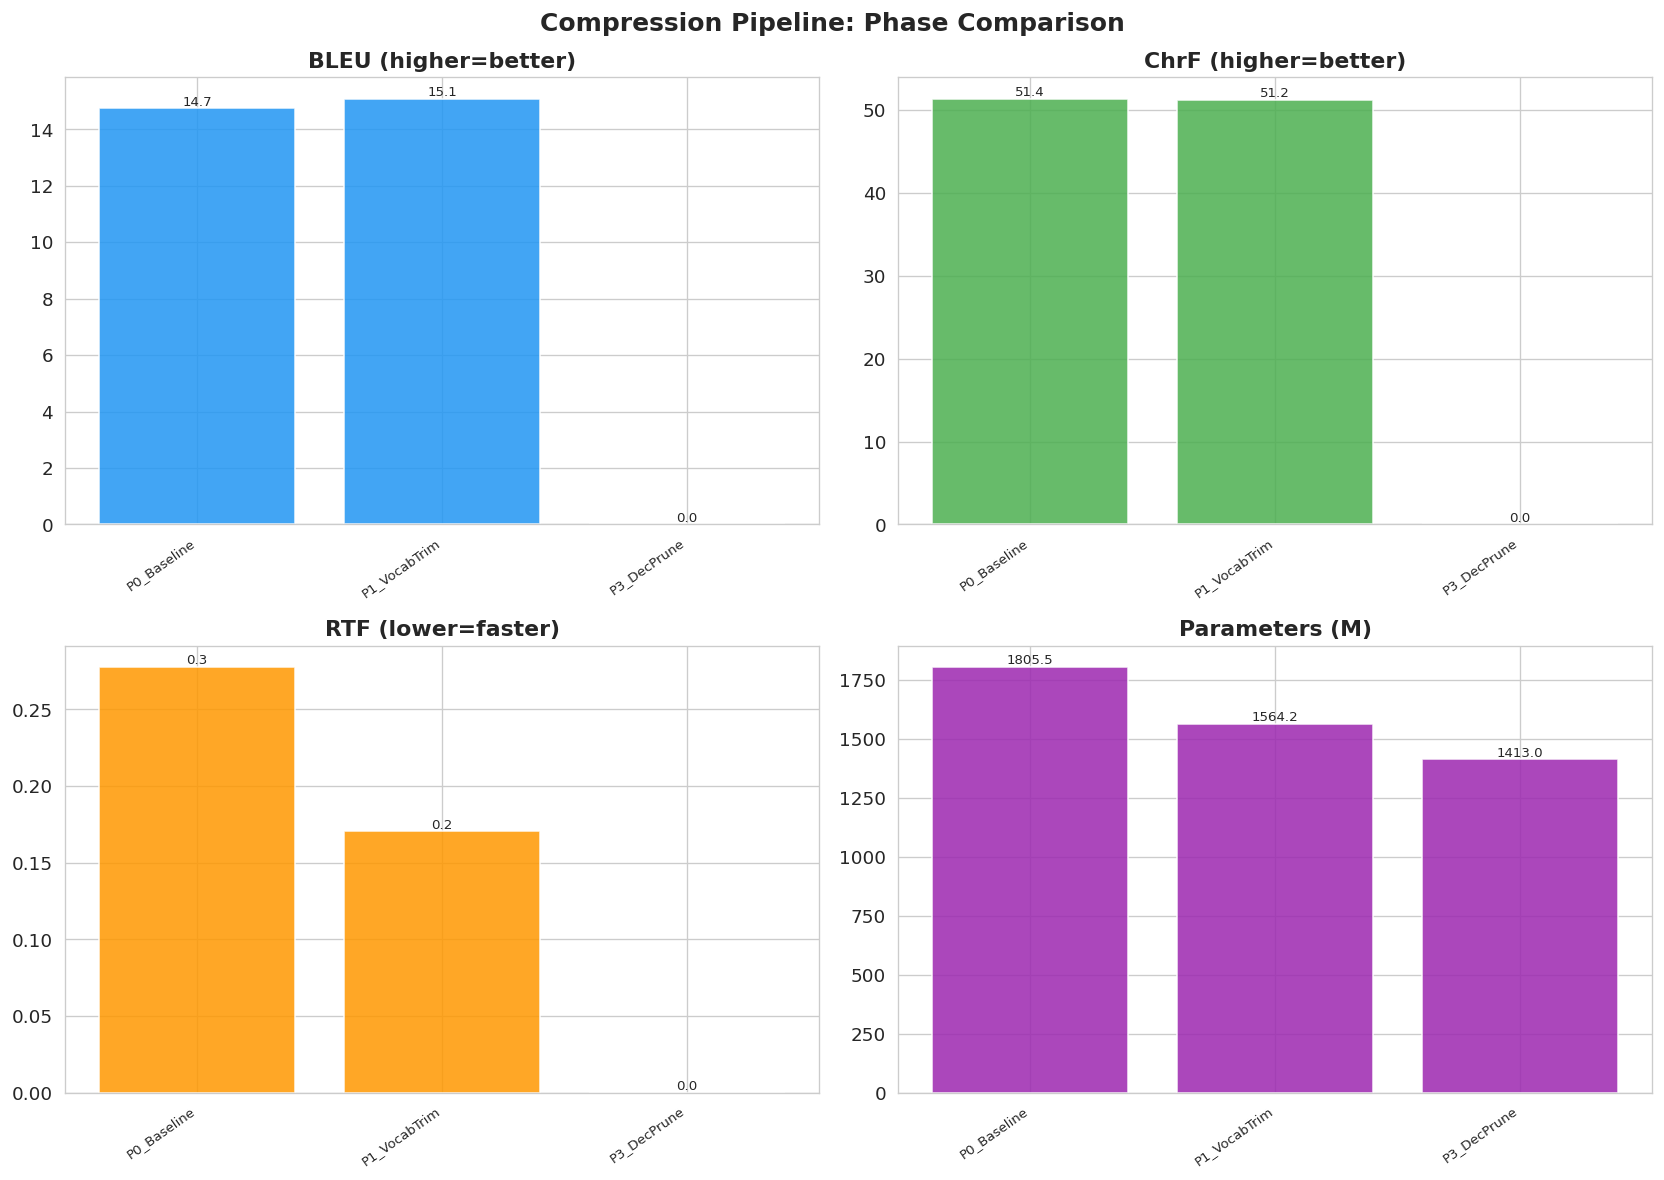

In [61]:
baseline_ckpt = load_latest_checkpoint('phase0_baseline')
if baseline_ckpt:
    baseline_results = baseline_ckpt['results']
    baseline_summary = baseline_ckpt['summary']
    print(f'Loaded baseline: BLEU={baseline_summary["avg_bleu"]:.2f}')
else:
    baseline_results, baseline_summary = run_benchmark(
        model, eval_samples, label='P0_Baseline', save_n=2)
    save_checkpoint(dict(results=baseline_results, summary=baseline_summary,
                         breakdown=baseline_breakdown), name='phase0_baseline', step=0)

store_summary(baseline_summary)
plot_phase_comparison()

---
# Phase 1: Vocabulary / Embedding Pruning
**Paper:** Asahi et al. (EMNLP 2023)

NLLB vocabulary has **256,102 tokens** for ~100 languages.
We keep only ~5-7 languages. Trimming saves ~200M params with near-zero quality impact.

In [62]:
def identify_used_tokens(proc, target_lang_codes, n_corpus=2000):
    from datasets import load_dataset
    fleurs_codes = dict(eng='en_us', ben='bn_in', cmn='cmn_hans_cn',
                        fra='fr_fr', deu='de_de', hin='hi_in', urd='ur_pk')
    BASE = "hf://datasets/google/fleurs@refs%2Fconvert%2Fparquet"
    used = set()
    tok = proc.tokenizer
    if hasattr(tok, 'all_special_ids'): used.update(tok.all_special_ids)
    for tid in range(len(tok)):
        t = tok.convert_ids_to_tokens(tid)
        if t and t.startswith('__') and t.endswith('__'): used.add(tid)
    for lang, fc in fleurs_codes.items():
        if lang not in target_lang_codes: continue
        print(f'  Scanning {lang} ({fc})...')
        try:
            ds = load_dataset("parquet",
                              data_files={"train": f"{BASE}/{fc}/train/*.parquet"},
                              split="train")
            for i, ex in enumerate(ds):
                if i >= n_corpus: break
                text = ex.get('transcription', '')
                if text: used.update(tok.encode(text, add_special_tokens=False))
        except Exception as e:
            print(f'    Warning: {lang}: {e}')
    print(f'  Unique tokens: {len(used)} / {len(tok)}')
    return sorted(used)


def trim_vocabulary(mdl, proc, keep_ids):
    """
    Trim the NLLB text vocabulary to only the kept token IDs.

    Correctly handles:
    - SeamlessM4Tv2ScaledWordEmbedding (preserves embed_scale for decoder)
    - generation_config.id_to_text mapping (required by T2U _indices_to_subwords)
    - Tied weights: shared <-> text_decoder.embed_tokens <-> lm_head
    - Correct padding_idx remapping from old to new ID space

    Based on Asahi et al. (EMNLP 2023) vocabulary trimming methodology.
    """
    keep_t = torch.tensor(keep_ids, dtype=torch.long)
    old_v = mdl.config.vocab_size
    new_v = len(keep_ids)
    hidden = mdl.config.hidden_size
    print(f'  Vocabulary: {old_v} -> {new_v} ({new_v/old_v*100:.1f}%)')

    old_shared = mdl.shared
    if old_shared.num_embeddings != old_v:
        print(f'  ERROR: shared.num_embeddings={old_shared.num_embeddings}, '
              f'expected {old_v}. Reload base model first.')
        return mdl

    dev = old_shared.weight.device
    dtype = old_shared.weight.dtype
    keep_t_dev = keep_t.to(dev)

    old_to_new = {old_id: new_id for new_id, old_id in enumerate(keep_ids)}

    old_pad = old_shared.padding_idx
    new_pad = old_to_new.get(old_pad) if old_pad is not None else None
    if old_pad is not None and new_pad is None:
        print(f'  WARNING: pad token {old_pad} not in keep_ids!')

    embed_scale = getattr(mdl.text_decoder.embed_tokens, 'embed_scale', 1.0)
    print(f'  text_decoder.embed_tokens.embed_scale = {embed_scale}')

    # --- 1. Create trimmed shared embedding ---
    new_shared = nn.Embedding(new_v, hidden, padding_idx=new_pad)
    new_shared.weight.data = old_shared.weight.data[keep_t_dev].clone()
    mdl.shared = new_shared.to(device=dev, dtype=dtype)
    print(f'  shared: [{old_v}, {hidden}] -> [{new_v}, {hidden}]')

    # --- 2. Update text_decoder.embed_tokens IN-PLACE ---
    # Keeps the SeamlessM4Tv2ScaledWordEmbedding class and its embed_scale.
    # The original forward() multiplies by embed_scale ~32.0;
    # replacing with plain nn.Embedding would lose this scaling entirely.
    dec_emb = mdl.text_decoder.embed_tokens
    dec_emb.weight = mdl.shared.weight
    dec_emb.num_embeddings = new_v
    dec_emb.padding_idx = new_pad
    print(f'  text_decoder.embed_tokens: tied to shared, embed_scale={dec_emb.embed_scale}')

    # --- 3. Handle text_encoder.embed_tokens if present ---
    if hasattr(mdl, 'text_encoder') and mdl.text_encoder is not None:
        enc_emb = getattr(mdl.text_encoder, 'embed_tokens', None)
        if enc_emb is not None:
            enc_emb.weight = mdl.shared.weight
            enc_emb.num_embeddings = new_v
            enc_emb.padding_idx = new_pad
            print(f'  text_encoder.embed_tokens: tied to shared')

    # --- 4. Tie lm_head to shared (preserves original tied-weight architecture) ---
    mdl.lm_head.weight = mdl.shared.weight
    mdl.lm_head.out_features = new_v
    if mdl.lm_head.bias is not None:
        mdl.lm_head.bias = nn.Parameter(mdl.lm_head.bias.data[keep_t_dev].clone())
    print(f'  lm_head: tied to shared [{new_v}, {hidden}]')

    # --- 5. Update model config ---
    mdl.config.vocab_size = new_v
    for attr in ['pad_token_id', 'bos_token_id', 'eos_token_id', 'decoder_start_token_id']:
        old_id = getattr(mdl.config, attr, None)
        if old_id is not None and old_id in old_to_new:
            setattr(mdl.config, attr, old_to_new[old_id])

    if hasattr(mdl.text_decoder, 'vocab_size'):
        mdl.text_decoder.vocab_size = new_v
    if hasattr(mdl.text_decoder, 'padding_idx'):
        mdl.text_decoder.padding_idx = new_pad
    print(f'  config: vocab_size={new_v}')

    # --- 6. Update generation_config ---
    gc = mdl.generation_config

    # 6a. text_decoder_lang_to_code_id (lang -> text-vocab token ID for decoder_input)
    if hasattr(gc, 'text_decoder_lang_to_code_id') and gc.text_decoder_lang_to_code_id:
        gc.text_decoder_lang_to_code_id = {
            lang: old_to_new[oid]
            for lang, oid in gc.text_decoder_lang_to_code_id.items()
            if oid in old_to_new
        }
        print(f'  text_decoder_lang_to_code_id: {len(gc.text_decoder_lang_to_code_id)} langs')

    # 6b. id_to_text (CRITICAL for T2U character-level input)
    #     generate() calls _indices_to_subwords(t2u_input_ids) which does:
    #       id_to_text.get(str(token_id)) for each generated text token
    #     Without remapping, every lookup returns None -> T2U gets garbage chars
    if hasattr(gc, 'id_to_text') and gc.id_to_text:
        old_map = gc.id_to_text
        new_map = {}
        for key_str, text_val in old_map.items():
            old_id = int(key_str)
            if old_id in old_to_new:
                new_map[str(old_to_new[old_id])] = text_val
        gc.id_to_text = new_map
        print(f'  id_to_text: {len(old_map)} -> {len(new_map)} entries')
    else:
        print(f'  WARNING: no id_to_text in generation_config (T2U may fail for S2ST)')

    # 6c. Special token IDs in generation_config
    for attr in ['pad_token_id', 'bos_token_id', 'eos_token_id',
                 'decoder_start_token_id', 'forced_bos_token_id']:
        old_id = getattr(gc, attr, None)
        if old_id is not None and old_id in old_to_new:
            setattr(gc, attr, old_to_new[old_id])
    print(f'  generation_config special tokens remapped')

    # --- 7. Store remap for decode-time NEW->OLD conversion ---
    # _remap_ids_for_decode() maps model output (new IDs) back to original tokenizer
    # IDs for batch_decode. The tokenizer itself stays in original ID space.
    mdl._vocab_remap_to_old = torch.tensor(keep_ids, dtype=torch.long)

    saved_params = (old_v - new_v) * hidden / 1e6
    print(f'  Done: ~{saved_params:.0f}M shared-embedding params removed '
          f'(lm_head tied, not double-counted)')
    return mdl


print('Vocab trimming functions ready.')


Vocab trimming functions ready.


In [63]:
try:
    model_p1, processor = load_model_from_drive('phase1_vocab_trimmed')
    p1_ckpt = load_latest_checkpoint('phase1_vocab')
    if p1_ckpt and 'keep_ids' in p1_ckpt:
        keep_ids = p1_ckpt['keep_ids']
        model_p1._vocab_remap_to_old = torch.tensor(keep_ids, dtype=torch.long)
        print(f'  Restored vocab remap ({len(keep_ids)} tokens)')

        # Validate id_to_text was correctly remapped (guards against stale saves
        # from the old broken trim_vocabulary that didn't remap id_to_text)
        gc = model_p1.generation_config
        if hasattr(gc, 'id_to_text') and gc.id_to_text:
            max_key = max(int(k) for k in gc.id_to_text.keys())
            if max_key >= model_p1.config.vocab_size:
                print(f'  WARNING: id_to_text has stale keys (max={max_key} >= vocab_size={model_p1.config.vocab_size})')
                print(f'  Re-remapping id_to_text from checkpoint keep_ids...')
                old_to_new = {old_id: new_id for new_id, old_id in enumerate(keep_ids)}
                old_map = gc.id_to_text
                new_map = {}
                for key_str, text_val in old_map.items():
                    old_id = int(key_str)
                    if old_id in old_to_new:
                        new_map[str(old_to_new[old_id])] = text_val
                gc.id_to_text = new_map
                print(f'  Fixed id_to_text: {len(old_map)} -> {len(new_map)} entries')
    print('Loaded Phase 1 model from Drive.')
except Exception as e:
    print(f'Load failed ({e}), running vocab trimming...')
    if model.config.vocab_size != 256102:
        print(f'  Model vocab is {model.config.vocab_size}, expected 256102. Reloading base model...')
        model, processor = load_base_model()
    TARGET_LANGS = ['eng', 'ben', 'cmn', 'fra', 'hin']
    keep_ids = identify_used_tokens(processor, TARGET_LANGS)
    pre = count_params(model)
    model = trim_vocabulary(model, processor, keep_ids)
    post = count_params(model)
    print(f'  Params: {pre:.1f}M to {post:.1f}M (saved {pre-post:.1f}M)')
    save_checkpoint(dict(keep_ids=keep_ids, pre=pre, post=post), name='phase1_vocab', step=0)
    save_model_to_drive(model, processor, 'phase1_vocab_trimmed')
    model_p1 = model

print_model_breakdown(model_p1, 'After Phase 1: Vocab Trimmed')


[model] Loading phase1_vocab_trimmed...


Loading weights:   0%|          | 0/1846 [00:00<?, ?it/s]

  Restored custom state: ['_vocab_remap_to_old']
[ckpt] Loaded phase1_vocab_step000000.pt
  Restored vocab remap (20425 tokens)
Loaded Phase 1 model from Drive.

--- After Phase 1: Vocab Trimmed ---
  speech_encoder                         635.0M  ( 40.6%)
  text_decoder                           625.5M  ( 40.0%)
  t2u_model                              261.8M  ( 16.7%)
  vocoder                                 41.9M  (  2.7%)
  shared                                  20.9M  (  1.3%)
  lm_head                                 20.9M  (  1.3%)
  TOTAL                                 1564.2M
---


{'shared': 20.9152,
 'speech_encoder': 635.04672,
 'text_decoder': 625.462272,
 'lm_head': 20.9152,
 't2u_model': 261.759747,
 'vocoder': 41.911362,
 'TOTAL': 1564.180101}

Deleted stale: /kaggle/working/checkpoints/phase1_benchmark_step000000.pt
[ckpt] No checkpoint for 'phase1_benchmark'

  BENCHMARK: P1_VocabTrim
  Samples: 20  Target: ben

  GPU mem: 7.12 GB alloc / 7.14 GB reserved
  [ 1/20] BLEU= 10.7 ChrF= 49.2 RTF=0.154  id=1660
              pred: রোমান্টিকতাবাদ গথ, ফিচ্ট এবং শ্লেগেলের মতো লেখকদের কাছ থেকে নেওয়া সাংস্কৃতিক নি
[audio] P1_VocabTrim_s1in.wav (0.3 MB)
  P1_VocabTrim_s1in.wav  (10.7s | sr=16000)


[audio] P1_VocabTrim_s1out.wav (0.2 MB)
  P1_VocabTrim_s1out.wav  (7.4s | sr=16000)


  [ 2/20] BLEU= 16.5 ChrF= 57.3 RTF=0.188  id=1662
              pred: অ্যালোয়গুলি মূলত দুটি বা ততোধিক ধাতুর মিশ্রণ, পিরিয়ডিক টেবিলে অনেকগুলি উপাদান 
[audio] P1_VocabTrim_s2in.wav (0.3 MB)
  P1_VocabTrim_s2in.wav  (8.4s | sr=16000)


[audio] P1_VocabTrim_s2out.wav (0.2 MB)
  P1_VocabTrim_s2out.wav  (6.6s | sr=16000)


  [ 3/20] BLEU=  3.7 ChrF= 31.0 RTF=0.186  id=1674
              pred: কিছু অঞ্চলে এক মিনিটের জন্য উষ্ণ জল যথেষ্ট এবং অন্যদের কয়েক মিনিটের প্রয়োজন হয
  [ 4/20] BLEU=  7.6 ChrF= 40.4 RTF=0.173  id=1675
              pred: শব্দটির পাশে থাকা সমস্ত নামগুলি আপনাকে বলে যে আপনি সর্বদা একটি বড় অক্ষর দিয়ে শ
  [ 5/20] BLEU=  5.0 ChrF= 26.3 RTF=0.166  id=1720
              pred: গরম চকোলেট বেলজিয়ামের মান অনুযায়ী। ফলের রস দামী কিন্তু চমৎকার।
  [ 6/20] BLEU=  2.7 ChrF= 22.1 RTF=0.183  id=1732
              pred: এই যুগকে সাধারণত উচ্চ মধ্যযুগ বা উচ্চ মধ্যযুগ বা উচ্চ মধ্যযুগ বা উচ্চ মধ্যযুগ বা
  [ 7/20] BLEU= 17.5 ChrF= 63.4 RTF=0.140  id=1740
              pred: পিরামিড সাউন্ড অ্যান্ড লাইট শো এই এলাকার শিশুদের জন্য সবচেয়ে আকর্ষণীয় বিষয়গুল
  [ 8/20] BLEU=  9.6 ChrF= 53.2 RTF=0.188  id=1794
              pred: একটি সভ্যতা হল একটি অনন্য সংস্কৃতি যা একটি সমাজের একটি উল্লেখযোগ্য বড় গোষ্ঠীর দ
  [ 9/20] BLEU= 22.6 ChrF= 61.7 RTF=0.115  id=1797
              pred: সবাই সমাজে অংশগ্রহণ করে এবং পরিবহ

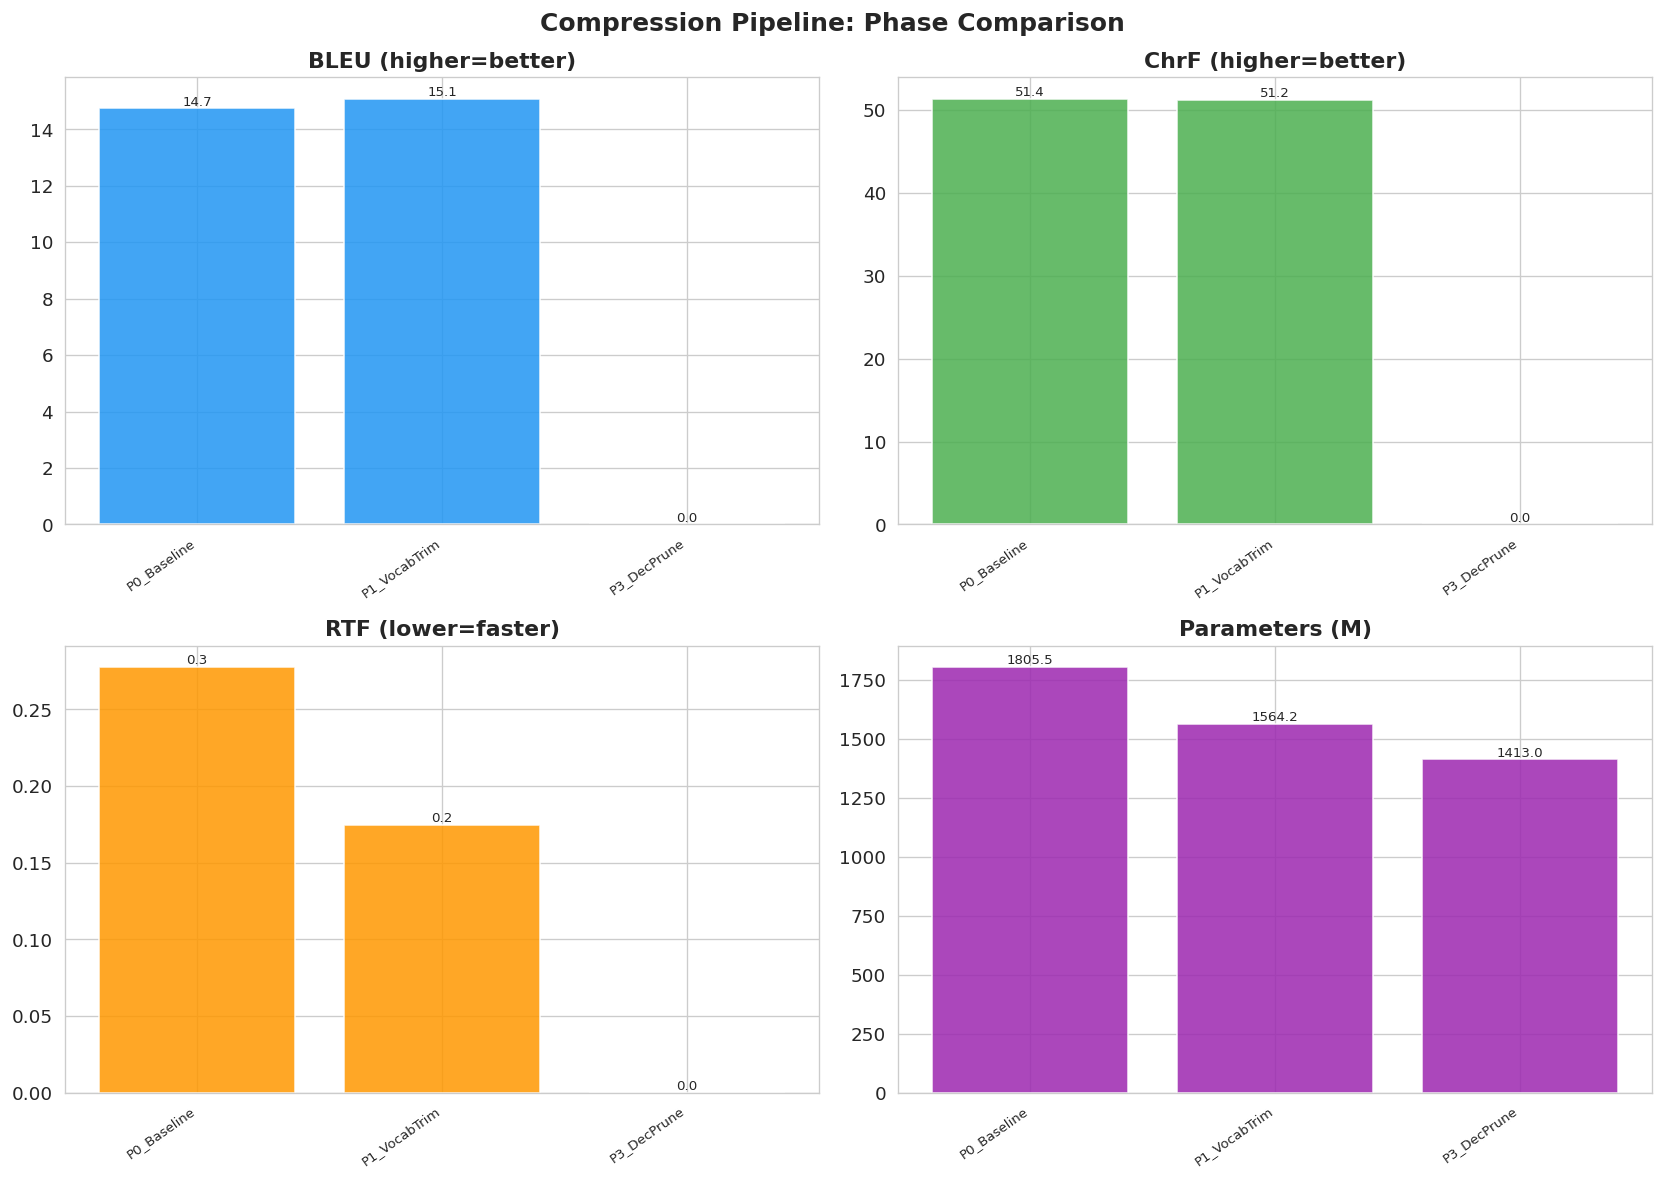

In [64]:
for f in glob.glob(f'{CKPT_DIR}/phase1_benchmark_step*.pt'):
    os.remove(f); print(f'Deleted stale: {f}')

p1_ckpt = load_latest_checkpoint('phase1_benchmark')
if p1_ckpt and p1_ckpt['summary'].get('avg_bleu', 0) > 0:
    p1_results, p1_summary = p1_ckpt['results'], p1_ckpt['summary']
else:
    p1_results, p1_summary = run_benchmark(model_p1, eval_samples, label='P1_VocabTrim', save_n=2)
    save_checkpoint(dict(results=p1_results, summary=p1_summary), name='phase1_benchmark', step=0)
store_summary(p1_summary)
plot_phase_comparison()

In [65]:
# import shutil
# stale = f'{MODEL_DIR}/phase1_vocab_trimmed'
# if os.path.exists(stale):
#     shutil.rmtree(stale)
#     print(f'Deleted stale: {stale}')
# # Also clear from Drive:
# subprocess.run(f'rclone delete {GDRIVE_ROOT}/phase1_vocab_trimmed/', shell=True)

---
# Phase 2: Text Encoder Removal
# Actually it was never in the first place, we never loaded the textEncoder as we are using 
# from transformers import SeamlessM4Tv2ForSpeechToSpeech
For S2S, the pipeline is: Speech Encoder -> Text Decoder -> T2U -> Vocoder.
The text_encoder is only used for T2T/T2S tasks. We verify and remove it.

In [66]:
# def check_text_encoder_used(mdl):
#     if not hasattr(mdl, 'text_encoder') or mdl.text_encoder is None:
#         print('  text_encoder not present.'); return False
#     called = [False]
#     def hook(mod, inp, out): called[0] = True
#     h = mdl.text_encoder.register_forward_hook(hook)
#     try: _ = run_s2st(mdl, np.random.randn(48000).astype(np.float32), 'ben')
#     except: pass
#     h.remove()
#     return called[0]

# def remove_text_encoder(mdl):
#     if hasattr(mdl, 'text_encoder') and mdl.text_encoder is not None:
#         enc_p = count_params(mdl.text_encoder)
#         del mdl.text_encoder; mdl.text_encoder = None
#         gc.collect(); torch.cuda.empty_cache()
#         print(f'  Removed text_encoder ({enc_p:.1f}M params)')
#     return mdl

# print('Text encoder analysis ready.')

In [67]:
# try:
#     model_p2, processor = load_model_from_drive('phase2_no_text_enc')
#     print('Loaded Phase 2 from Drive.')
# except:
#     model_p2 = model_p1
#     used = check_text_encoder_used(model_p2)
#     print(f'  text_encoder used in S2S: {used}')
#     if not used:
#         print('  Safe to remove for S2S-only.')
#         model_p2 = remove_text_encoder(model_p2)
#     else:
#         print('  text_encoder IS used. Keeping 8 of 24 layers.')
#         layers = model_p2.text_encoder.layers
#         keep = list(range(4)) + list(range(len(layers)-4, len(layers)))
#         model_p2.text_encoder.layers = nn.ModuleList([layers[i] for i in keep])
#     save_model_to_drive(model_p2, processor, 'phase2_no_text_enc')

# print_model_breakdown(model_p2, 'After Phase 2: Text Encoder Removed')

In [68]:
# p2_ckpt = load_latest_checkpoint('phase2_benchmark')
# if p2_ckpt:
#     p2_results, p2_summary = p2_ckpt['results'], p2_ckpt['summary']
# else:
#     p2_results, p2_summary = run_benchmark(model_p2, eval_samples, label='P2_NoTextEnc', save_n=2)
#     save_checkpoint(dict(results=p2_results, summary=p2_summary), name='phase2_benchmark', step=0)
# store_summary(p2_summary)
# plot_phase_comparison()

---
# Phase 3: Text Decoder Iterative Layer Pruning
**Paper:** Moslem (IWSLT 2025), CULL-MT (2024)

Iterative greedy pruning: remove one layer at a time, evaluate ChrF, repeat.
Target: remove 6-8 of 24 text decoder layers.

In [69]:
def find_layers_attr(component):
    for attr in ['layers', 'layer', 'inner_layers', 'encoder_layers', 'decoder_layers']:
        if hasattr(component, attr): return attr
    return None

def iterative_layer_prune(mdl, component_name, samples, n_remove,
                          tgt_lang='ben', max_eval=10,
                          ckpt_name='phase3_dec_pruning'):
    """
    Iterative greedy layer pruning (Moslem, IWSLT 2025).
    Removes one layer per iteration, picking the one whose removal
    causes the least ChrF degradation.
    Saves a checkpoint after every iteration so progress survives crashes.
    """
    parent = getattr(mdl, component_name)
    layers_attr = find_layers_attr(parent)
    if layers_attr is None:
        print(f'  No layers found on {component_name}'); return [], []
    current = list(getattr(parent, layers_attr))
    orig_indices = list(range(len(current)))
    removed, log = [], []

    partial = load_latest_checkpoint(ckpt_name)
    if partial and partial.get('removed'):
        removed = partial['removed']
        log = partial.get('log', [])
        for r in removed:
            if r in orig_indices:
                pos = orig_indices.index(r)
                current.pop(pos)
                orig_indices.pop(pos)
        setattr(parent, layers_attr, nn.ModuleList(current))
        print(f'  Resuming: already removed {removed}, {len(current)} layers remain')

    start_iter = len(removed)
    for it in range(start_iter, n_remove):
        print(f'\n  Iter {it+1}/{n_remove} ({len(current)} layers remain)')
        scores = {}
        for idx in range(len(current)):
            temp = current[:idx] + current[idx+1:]
            setattr(parent, layers_attr, nn.ModuleList(temp))
            sc = quick_eval_chrf(mdl, samples, tgt_lang, max_eval)
            scores[idx] = (orig_indices[idx], sc)
            print(f'    Remove L{orig_indices[idx]:>2} -> ChrF={sc:.2f}')
        setattr(parent, layers_attr, nn.ModuleList(current))

        best_idx = max(scores, key=lambda k: scores[k][1])
        best_orig, best_sc = scores[best_idx]
        current.pop(best_idx)
        orig_indices.pop(best_idx)
        setattr(parent, layers_attr, nn.ModuleList(current))
        removed.append(best_orig)
        log.append(dict(iter=it+1, removed=best_orig, chrf=best_sc,
                        remaining=len(current)))
        print(f'  -> Removed layer {best_orig} (ChrF={best_sc:.2f})')
        save_checkpoint(dict(removed=removed, log=log), name=ckpt_name, step=0)
        print(f'  [ckpt] Progress saved ({it+1}/{n_remove} iterations done)')

    return removed, log

print('iterative_layer_prune() ready.')

iterative_layer_prune() ready.


In [70]:
N_DEC_REMOVE = 6

p3_ckpt = load_latest_checkpoint('phase3_dec_pruning')
p3_complete = p3_ckpt and len(p3_ckpt.get('removed', [])) >= N_DEC_REMOVE

if p3_complete:
    removed_dec = p3_ckpt['removed']; p3_log = p3_ckpt['log']
    print(f'Phase 3 complete: removed {removed_dec}')
    try:
        model_p3, processor = load_model_from_drive('phase3_dec_pruned')
    except:
        print('  Drive model missing, rebuilding from checkpoint + model_p1...')
        model_p3 = model_p1
        parent = model_p3.text_decoder
        la = find_layers_attr(parent)
        cur = list(getattr(parent, la))
        keep = [i for i in range(len(cur)) if i not in removed_dec]
        setattr(parent, la, nn.ModuleList([cur[i] for i in keep]))
        save_model_to_drive(model_p3, processor, 'phase3_dec_pruned')
else:
    if p3_ckpt:
        print(f'Resuming Phase 3: {len(p3_ckpt["removed"])}/{N_DEC_REMOVE} done so far...')
    else:
        print(f'Running Phase 3: decoder pruning ({N_DEC_REMOVE} layers)...')
    model_p3 = _consolidate_to_single_gpu(model_p1)
    removed_dec, p3_log = iterative_layer_prune(
        model_p3, 'text_decoder', eval_samples, N_DEC_REMOVE, TARGET_LANG)
    save_model_to_drive(model_p3, processor, 'phase3_dec_pruned')

print(f'Decoder layers removed: {removed_dec}')
print_model_breakdown(model_p3, 'After Phase 3: Decoder Pruned')

[ckpt] Loaded phase3_dec_pruning_step000000.pt
Phase 3 complete: removed [7, 1, 9, 23, 17, 19]
[model] Loading phase3_dec_pruned...


Loading weights:   0%|          | 0/1690 [00:00<?, ?it/s]

  Restored custom state: ['_vocab_remap_to_old']
Decoder layers removed: [7, 1, 9, 23, 17, 19]

--- After Phase 3: Decoder Pruned ---
  speech_encoder                         635.0M  ( 44.9%)
  text_decoder                           474.3M  ( 33.6%)
  t2u_model                              261.8M  ( 18.5%)
  vocoder                                 41.9M  (  3.0%)
  shared                                  20.9M  (  1.5%)
  lm_head                                 20.9M  (  1.5%)
  TOTAL                                 1413.0M
---


{'shared': 20.9152,
 'speech_encoder': 635.04672,
 'text_decoder': 474.326016,
 'lm_head': 20.9152,
 't2u_model': 261.759747,
 'vocoder': 41.911362,
 'TOTAL': 1413.043845}

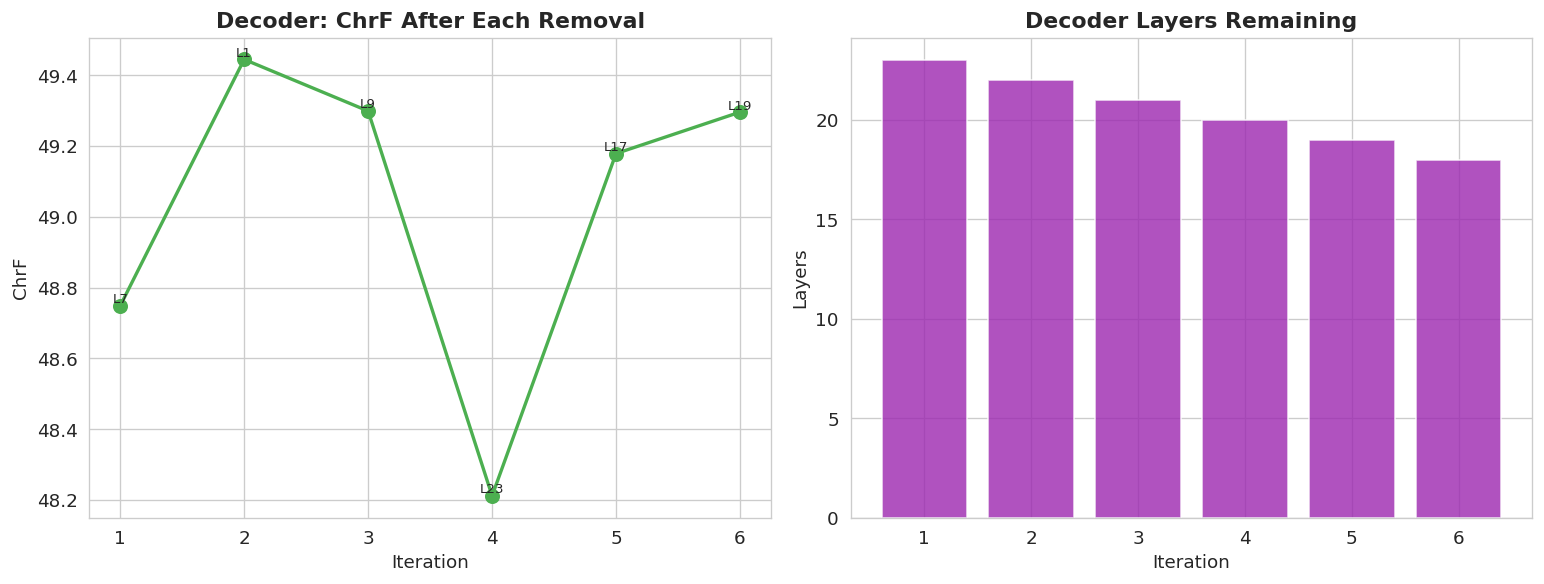

In [71]:
if p3_log:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    iters = [e['iter'] for e in p3_log]
    chrfs = [e['chrf'] for e in p3_log]
    ax1.plot(iters, chrfs, 'o-', color='#4CAF50', lw=2, ms=8)
    for e in p3_log: ax1.annotate(f'L{e["removed"]}', (e['iter'], e['chrf']), fontsize=8, ha='center', va='bottom')
    ax1.set_xlabel('Iteration'); ax1.set_ylabel('ChrF'); ax1.set_title('Decoder: ChrF After Each Removal', fontweight='bold')
    ax2.bar(iters, [e['remaining'] for e in p3_log], color='#9C27B0', alpha=0.8)
    ax2.set_xlabel('Iteration'); ax2.set_ylabel('Layers'); ax2.set_title('Decoder Layers Remaining', fontweight='bold')
    plt.tight_layout(); plt.savefig(f'{FIG_DIR}/phase3_dec.png'); plt.show()


  BENCHMARK: P3_DecPrune
  Samples: 20  Target: ben

  GPU mem: 9.00 GB alloc / 9.03 GB reserved
  [ 1/20] BLEU= 11.4 ChrF= 50.1 RTF=0.119  id=1660
              pred: রোমান্টিকবাদ গথ, ফিচ এবং শ্লেগেলের মতো লেখকদের থেকে প্রাপ্ত সাংস্কৃতিক নির্ধারিত
[audio] P3_DecPrune_s1in.wav (0.3 MB)
  P3_DecPrune_s1in.wav  (10.7s | sr=16000)


[audio] P3_DecPrune_s1out.wav (0.2 MB)
  P3_DecPrune_s1out.wav  (7.1s | sr=16000)


  [ 2/20] BLEU= 22.0 ChrF= 59.2 RTF=0.154  id=1662
              pred: অ্যালোয়েগুলি মূলত দুটি বা ততোধিক ধাতুর মিশ্রণ, একটি পিরিডিক টেবিলের অনেক উপাদান
[audio] P3_DecPrune_s2in.wav (0.3 MB)
  P3_DecPrune_s2in.wav  (8.4s | sr=16000)


[audio] P3_DecPrune_s2out.wav (0.2 MB)
  P3_DecPrune_s2out.wav  (6.7s | sr=16000)


  [ 3/20] BLEU=  3.7 ChrF= 36.5 RTF=0.159  id=1674
              pred: কিছু অঞ্চলে এক মিনিটের জন্য গরম পানি যথেষ্ট এবং অন্য কিছু জায়গায় কয়েক মিনিটের
  [ 4/20] BLEU=  7.2 ChrF= 40.5 RTF=0.116  id=1675
              pred: শব্দটির পাশে থাকা সমস্ত নাম সর্বদা একটি বড় আক্ষর দিয়ে শুরু করুন, এমনকি একটি বা
  [ 5/20] BLEU=  5.0 ChrF= 33.5 RTF=0.146  id=1720
              pred: গরম চকোলেট বেলজিয়ামের স্ট্যান্ডার্ডের মতো। ফলের রস দামী কিন্তু দুর্দান্ত।
  [ 6/20] BLEU=  4.2 ChrF= 48.9 RTF=0.112  id=1732
              pred: এই সময়কালকে সাধারণত উচ্চ মধ্যযুগ বা মধ্যযুগ বলা হয়, যা 11th, 12th এবং 13th শতা
  [ 7/20] BLEU= 16.1 ChrF= 61.0 RTF=0.116  id=1740
              pred: পিরামিডের সাউন্ড এন্ড লাইট শো এই এলাকার শিশুদের জন্য সবচেয়ে আকর্ষণীয় বিষয়গুলি
  [ 8/20] BLEU= 29.8 ChrF= 57.9 RTF=0.132  id=1794
              pred: একটি সভ্যতা একটি একক সংস্কৃতি যা একটি সমাজের একটি উল্লেখযোগ্য বড় গ্রুপ দ্বারা শ
  [ 9/20] BLEU= 22.6 ChrF= 61.7 RTF=0.092  id=1797
              pred: সবাই সমাজে অংশগ্রহণ করে

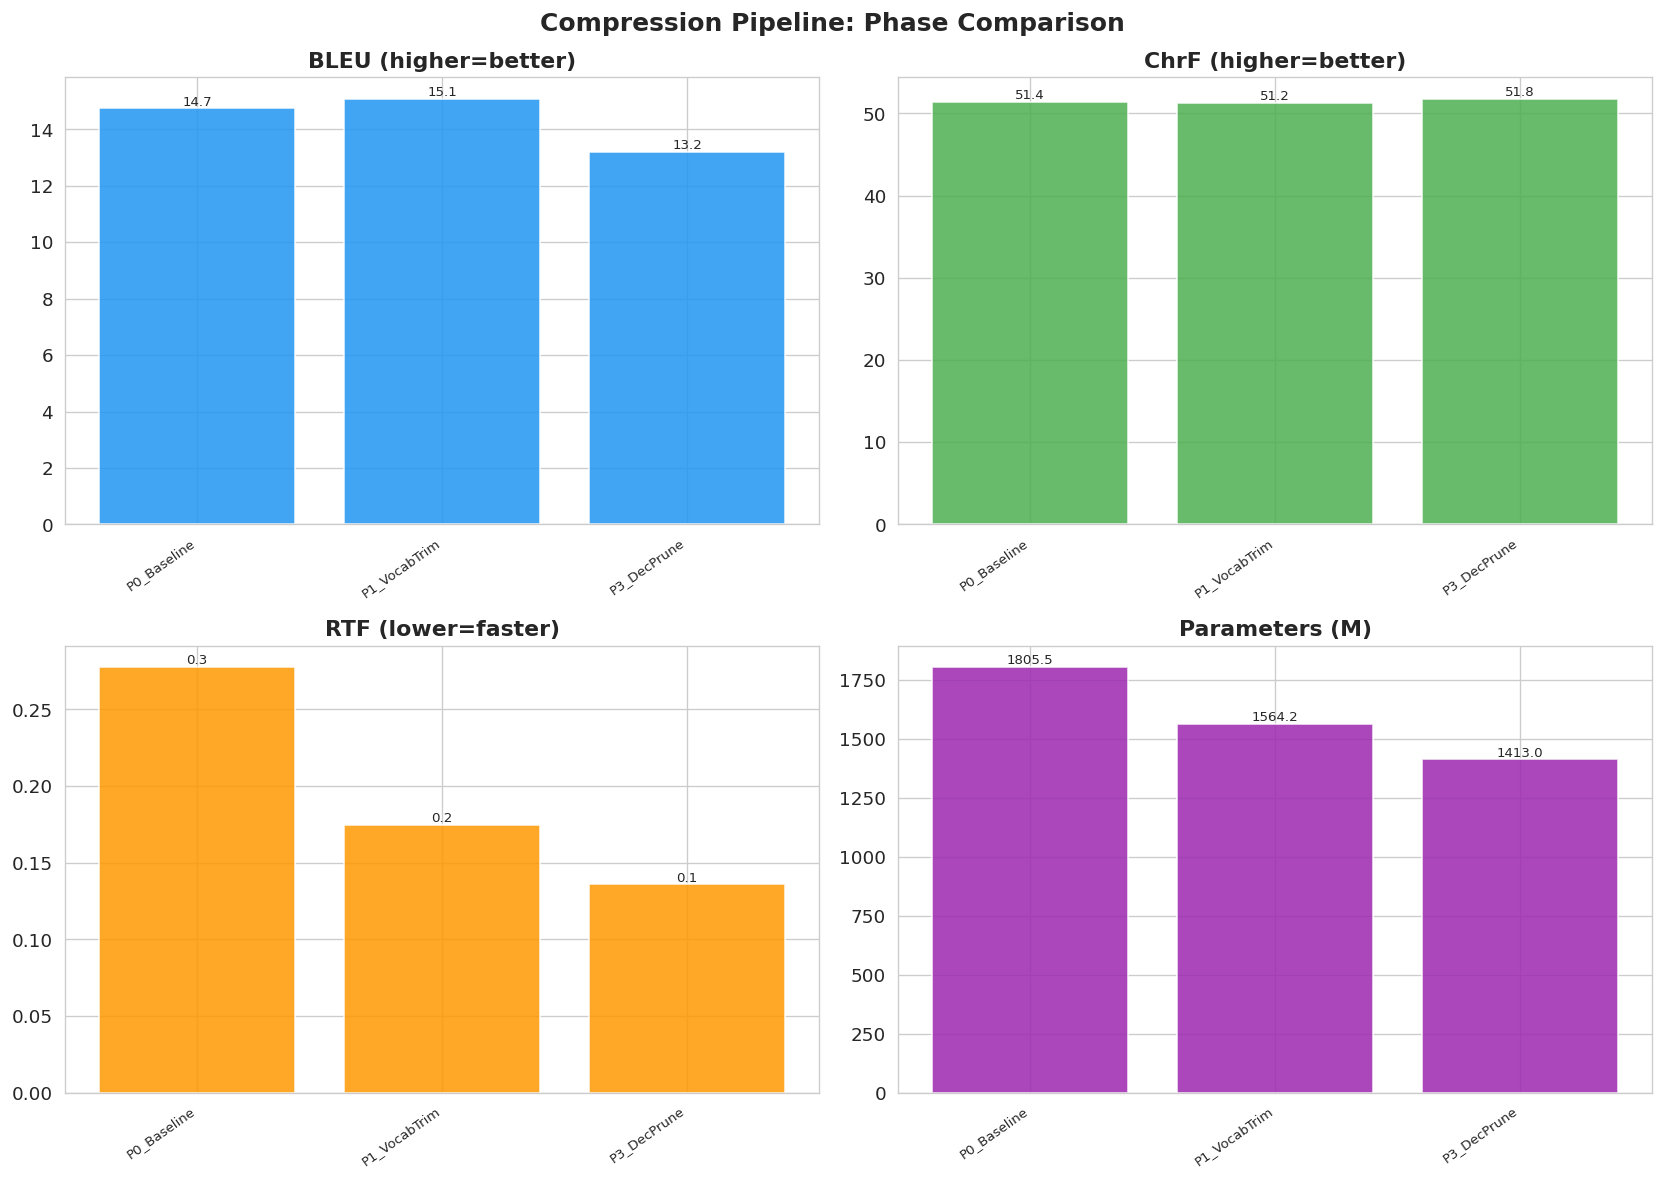

In [72]:
p3_results, p3_summary = run_benchmark(model_p3, eval_samples, label='P3_DecPrune', save_n=2)
save_checkpoint(dict(results=p3_results, summary=p3_summary), name='phase3_benchmark', step=0)
store_summary(p3_summary); plot_phase_comparison()

[ckpt] Loaded phase3_benchmark_step000000.pt
[ckpt] Saved all_summaries_step000000.pt (0.0 MB)
[summary] Stored P3_DecPrune (3 total)


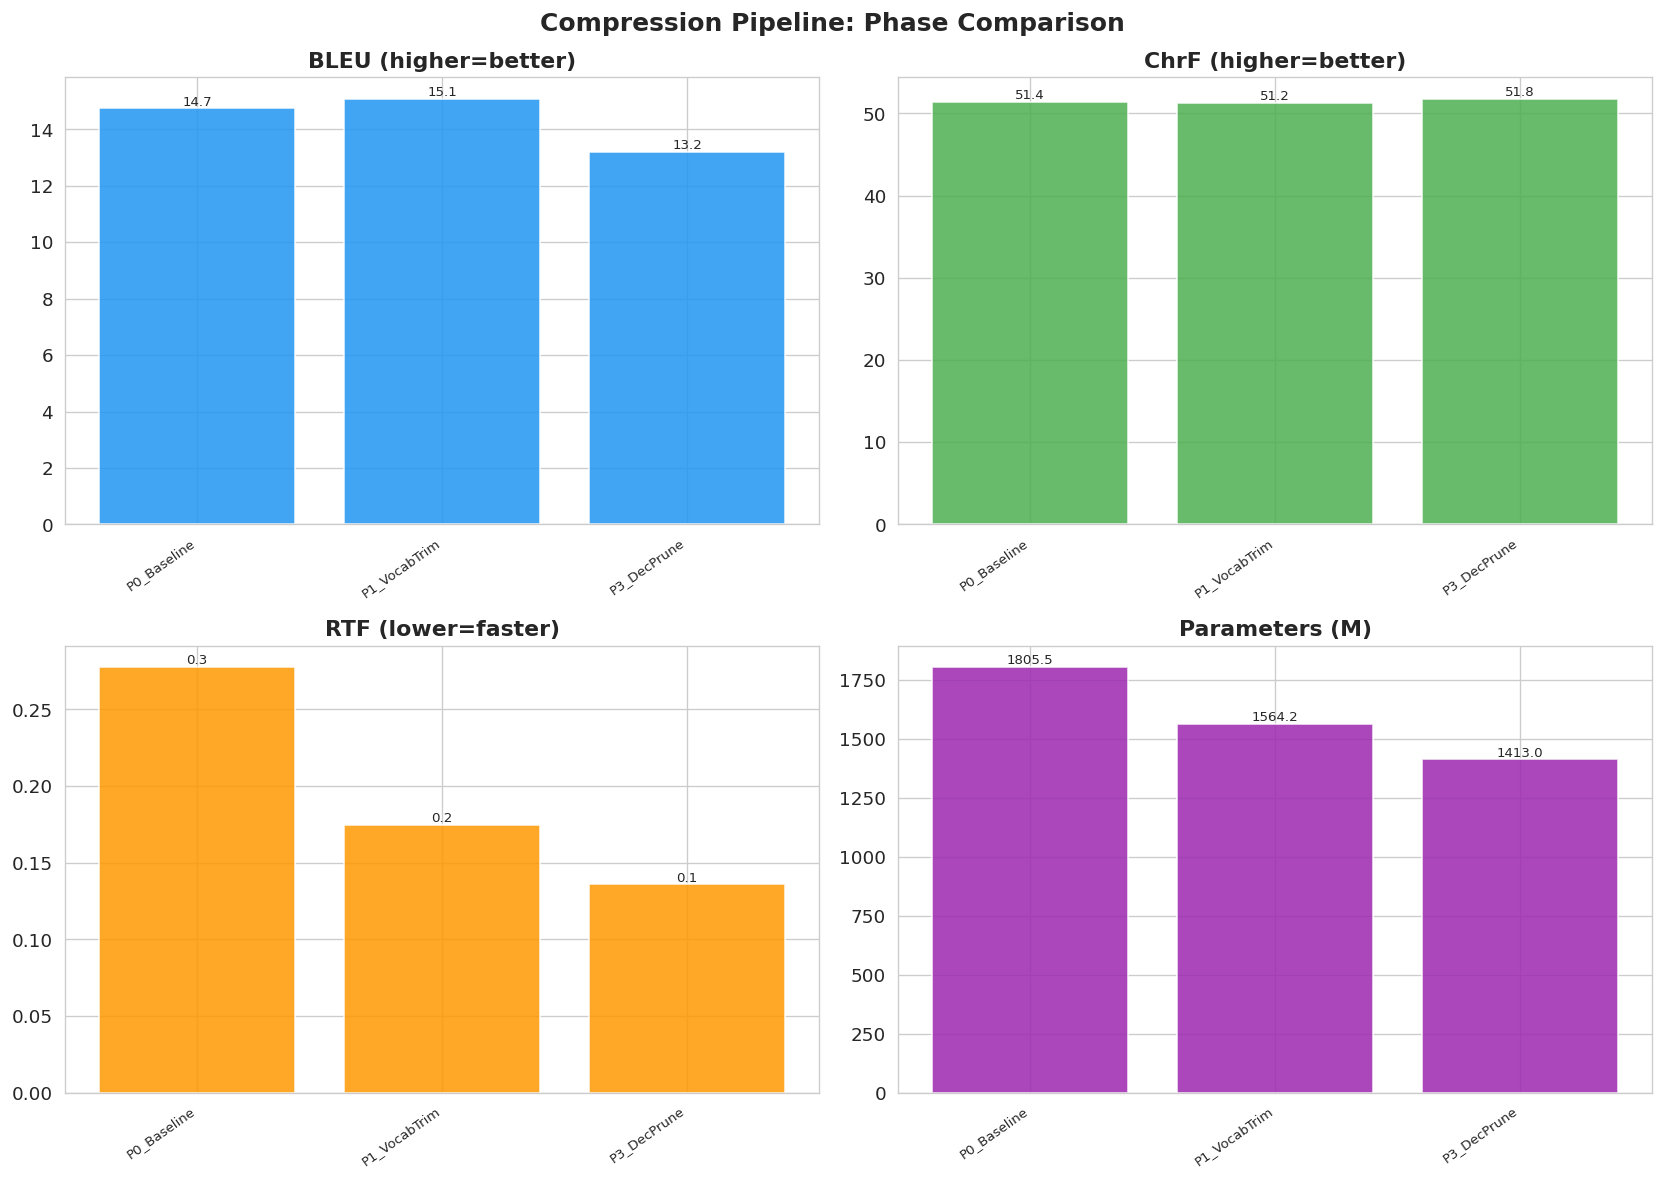

In [73]:
p3b = load_latest_checkpoint('phase3_benchmark')
if p3b: p3_results, p3_summary = p3b['results'], p3b['summary']
else:
    p3_results, p3_summary = run_benchmark(model_p3, eval_samples, label='P3_DecPrune', save_n=2)
    save_checkpoint(dict(results=p3_results, summary=p3_summary), name='phase3_benchmark', step=0)
store_summary(p3_summary); plot_phase_comparison()

---
# Phase 4: Speech Encoder Iterative Layer Pruning
**Paper:** ShortGPT (ACL 2025) for Block Influence; Moslem (IWSLT 2025) for iterative greedy

Target: remove 6-8 of 24 speech encoder layers.

In [74]:
def get_speech_encoder_layers(mdl):
    enc = mdl.speech_encoder
    if hasattr(enc, 'layers') and isinstance(enc.layers, torch.nn.ModuleList) and len(enc.layers) > 0:
        return enc, 'layers'
    if hasattr(enc, 'encoder') and hasattr(enc.encoder, 'layers') and len(enc.encoder.layers) > 0:
        return enc.encoder, 'layers'
    for child_name, child in enc.named_children():
        if hasattr(child, 'layers') and isinstance(child.layers, torch.nn.ModuleList) and len(child.layers) > 0:
            print(f'  Found layers at speech_encoder.{child_name}.layers')
            return child, 'layers'
    raise RuntimeError(
        f"Cannot find layers. speech_encoder children: "
        f"{[n for n,_ in enc.named_children()]}\n"
        f"encoder children: "
        f"{[n for n,_ in enc.encoder.named_children()] if hasattr(enc, 'encoder') else 'N/A'}"
    )


def compute_block_influence(mdl, samples, max_n=50):
    """
    Block Influence (ShortGPT, ACL 2025): BI(l) = 1 - cos(input_l, output_l).
    Runs ONLY the speech encoder forward — no decoder/vocoder needed.
    """
    parent, la = get_speech_encoder_layers(mdl)
    layers = getattr(parent, la)
    n = len(layers)
    bi = {i: [] for i in range(n)}
    hooks = []

    for i in range(n):
        def make_hook(idx):
            def hook(mod, inp, out):
                x = inp[0]
                if x is None or not isinstance(x, torch.Tensor): return
                y = out[0] if isinstance(out, tuple) else out
                if y is None or not isinstance(y, torch.Tensor): return
                x = x.detach().float().reshape(-1, x.shape[-1])
                y = y.detach().to(x.device).float().reshape(-1, y.shape[-1])
                cos = F.cosine_similarity(x, y, dim=-1).mean().item()
                bi[idx].append(1.0 - cos)
            return hook
        hooks.append(layers[i].register_forward_hook(make_hook(i)))

    mdl.eval()
    dev = next(mdl.speech_encoder.parameters()).device
    ok = 0
    for idx, s in enumerate(samples[:max_n]):
        if idx % 10 == 0:
            print(f'  Calibrating {idx}/{min(max_n, len(samples))}...')
        try:
            inputs = processor(audio=s['wav'], sampling_rate=16000, return_tensors='pt')
            feats = {k: v.to(dev) for k, v in inputs.items()}
            with torch.no_grad():
                mdl.speech_encoder(**feats)
            ok += 1
        except Exception as e:
            print(f'  Sample {idx} failed: {e}')

    for h in hooks: h.remove()

    scores = {i: float(np.mean(v)) if v else 0.0 for i, v in bi.items()}
    print(f'  Calibrated on {ok}/{min(max_n, len(samples))} samples.')
    nonzero = sum(1 for v in scores.values() if v > 1e-6)
    print(f'  Non-zero BI scores: {nonzero}/{n}')
    if nonzero == 0:
        raise RuntimeError("All BI scores are zero — hooks did not fire.")
    return scores


def iterative_enc_prune(mdl, samples, n_remove, tgt_lang='ben', max_eval=10,
                        ckpt_name='phase4_enc_pruning'):
    """
    Iterative greedy encoder pruning (Moslem, IWSLT 2025).
    Each iteration: try removing every remaining layer, keep the removal
    that yields the highest ChrF, then permanently remove it.
    Saves a checkpoint after every iteration so progress survives crashes.
    """
    parent, la = get_speech_encoder_layers(mdl)
    current  = list(getattr(parent, la))
    orig_idx = list(range(len(current)))
    removed, log = [], []

    partial = load_latest_checkpoint(ckpt_name)
    if partial and partial.get('removed'):
        removed = list(partial['removed'])
        log = partial.get('log', [])
        for r in removed:
            if r in orig_idx:
                pos = orig_idx.index(r)
                current.pop(pos)
                orig_idx.pop(pos)
        setattr(parent, la, torch.nn.ModuleList(current))
        print(f'  Resuming: already removed {removed}, {len(current)} layers remain')

    start_iter = len(removed)

    baseline = quick_eval_chrf(mdl, samples, tgt_lang, max_eval)
    print(f'  Baseline ChrF (before any removal): {baseline:.2f}')

    for it in range(start_iter, n_remove):
        print(f'\n  Iter {it+1}/{n_remove}  ({len(current)} layers remain)')
        scores = {}
        for pos in range(len(current)):
            temp = current[:pos] + current[pos+1:]
            setattr(parent, la, torch.nn.ModuleList(temp))
            sc = quick_eval_chrf(mdl, samples, tgt_lang, max_eval)
            scores[pos] = (orig_idx[pos], sc)
            print(f'    Remove L{orig_idx[pos]:>2} -> ChrF={sc:.2f}')
        setattr(parent, la, torch.nn.ModuleList(current))

        best_pos = max(scores, key=lambda k: scores[k][1])
        best_orig, best_sc = scores[best_pos]
        current.pop(best_pos)
        orig_idx.pop(best_pos)
        setattr(parent, la, torch.nn.ModuleList(current))
        removed.append(best_orig)
        log.append(dict(iter=it+1, removed=best_orig, chrf=best_sc,
                        remaining=len(current)))
        print(f'  -> Removed original layer {best_orig}  (ChrF={best_sc:.2f})')
        save_checkpoint(
            dict(removed=removed, log=log, bi_scores=partial.get('bi_scores', {}) if partial else {}),
            name=ckpt_name, step=0)
        print(f'  [ckpt] Progress saved ({it+1}/{n_remove} iterations done)')
        torch.cuda.empty_cache()

    return removed, log


print('Phase 4 helpers ready.')
parent, la = get_speech_encoder_layers(model_p3)
print(f'Speech encoder layers found: {len(getattr(parent, la))} at .speech_encoder.{type(parent).__name__}.{la}')

Phase 4 helpers ready.
Speech encoder layers found: 24 at .speech_encoder.SeamlessM4Tv2ConformerEncoder.layers


In [75]:
# Uncomment and run ONCE to wipe the corrupt Phase 4 results, then re-comment.

# 1. Local checkpoints
for f in glob.glob(f'{CKPT_DIR}/phase4_enc_pruning_step*.pt'):
    os.remove(f)
    print(f'Deleted local ckpt: {f}')

# 2. Local saved model
local_model = f'{MODEL_DIR}/phase4_enc_pruned'
if os.path.exists(local_model):
    import shutil
    shutil.rmtree(local_model)
    print(f'Deleted local model: {local_model}')

# 3. Drive checkpoints + model
subprocess.run('rclone delete gdrive:cse465v3/checkpoints/phase4_enc_pruning_step000000.pt',
               shell=True, capture_output=True, text=True)
subprocess.run('rclone purge gdrive:cse465v3/phase4_enc_pruned',
               shell=True, capture_output=True, text=True)

# 4. Verify
r = subprocess.run('rclone ls gdrive:cse465v3/checkpoints/', shell=True, capture_output=True, text=True)
print('Remaining checkpoints on Drive:')
print(r.stdout or '(none)')

ck = load_latest_checkpoint('phase4_enc_pruning')
print('Phase 4 checkpoint after cleanup:', ck)

Remaining checkpoints on Drive:
     1875 all_summaries_step000000.pt
    15781 phase3_benchmark_step000000.pt
    15973 phase1_benchmark_step000000.pt
     1713 phase3_dec_pruning_step000000.pt
    86349 phase1_vocab_step000000.pt
    16159 phase0_baseline_step000000.pt

[ckpt] No checkpoint for 'phase4_enc_pruning'
Phase 4 checkpoint after cleanup: None


In [76]:
# Run once to fix model_p3 in memory before phase 3 benchmark
sync_model_config(model_p3)

# Run once to fix model_p4 in memory before phase 4 benchmark  
sync_model_config(model_p4)

  [config] sync done.
  [config] sync done.


[ckpt] No checkpoint for 'phase4_enc_pruning'
Running Phase 4 from scratch...
  Multi-device map detected, consolidating to cuda:0...
  Model now on: cuda:0
  Sanity check ChrF = 43.94  (expect ~40-55, abort if < 10)
Step 1: Computing Block Influence scores...
  Calibrating 0/20...
  Calibrating 10/20...
  Calibrated on 20/20 samples.
  Non-zero BI scores: 24/24


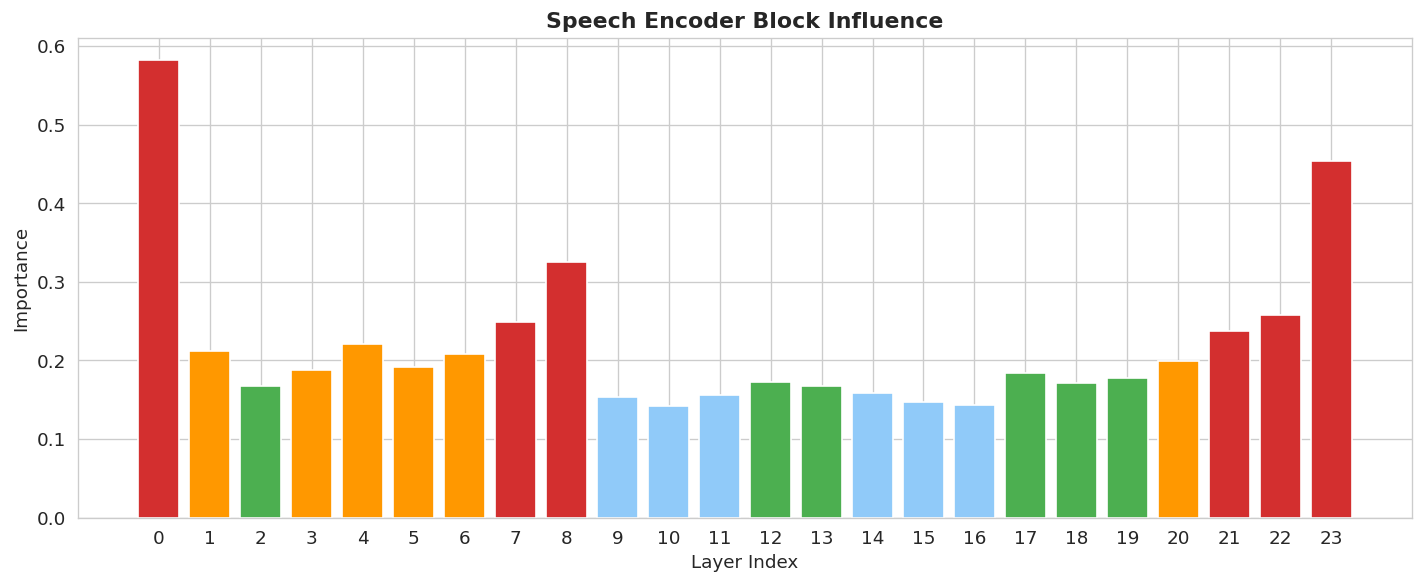


Step 2: Iterative pruning (6 layers)...
[ckpt] No checkpoint for 'phase4_enc_pruning'
  Baseline ChrF (before any removal): 49.30

  Iter 1/6  (24 layers remain)
    Remove L 0 -> ChrF=49.54
    Remove L 1 -> ChrF=49.18
    Remove L 2 -> ChrF=49.04
    Remove L 3 -> ChrF=49.05
    Remove L 4 -> ChrF=50.44
    Remove L 5 -> ChrF=49.53
    Remove L 6 -> ChrF=49.06
    Remove L 7 -> ChrF=49.34
    Remove L 8 -> ChrF=50.75
    Remove L 9 -> ChrF=48.43
    Remove L10 -> ChrF=49.34
    Remove L11 -> ChrF=49.78
    Remove L12 -> ChrF=47.62
    Remove L13 -> ChrF=49.51
    Remove L14 -> ChrF=49.90
    Remove L15 -> ChrF=48.65
    Remove L16 -> ChrF=49.83
    Remove L17 -> ChrF=49.59
    Remove L18 -> ChrF=49.54
    Remove L19 -> ChrF=49.73
    Remove L20 -> ChrF=48.53
    Remove L21 -> ChrF=49.30
    Remove L22 -> ChrF=47.89
    Remove L23 -> ChrF=48.91
  -> Removed original layer 8  (ChrF=50.75)
[ckpt] Saved phase4_enc_pruning_step000000.pt (0.0 MB)
  [ckpt] Progress saved (1/6 iterations do

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[model] Local OK: 2568 MB (7 files)  uploading...
[model] Done. Verified 7 files on Drive.

Encoder layers removed: [8, 18, 2, 9, 0, 19]

--- After Phase 4: Encoder Pruned ---
  speech_encoder                         490.0M  ( 38.6%)
  text_decoder                           474.3M  ( 37.4%)
  t2u_model                              261.8M  ( 20.6%)
  vocoder                                 41.9M  (  3.3%)
  shared                                  20.9M  (  1.6%)
  lm_head                                 20.9M  (  1.6%)
  TOTAL                                 1268.0M
---


{'shared': 20.9152,
 'speech_encoder': 489.964992,
 'text_decoder': 474.326016,
 'lm_head': 20.9152,
 't2u_model': 261.759747,
 'vocoder': 41.911362,
 'TOTAL': 1267.962117}

In [77]:
# ── Phase 4: Speech Encoder Iterative Layer Pruning ──────────────────────────
# Paper: ShortGPT (ACL 2025) for Block Influence; Moslem (IWSLT 2025) for
#        iterative greedy pruning guided by ChrF.

N_ENC_REMOVE = 6

p4_ckpt = load_latest_checkpoint('phase4_enc_pruning')
p4_complete = p4_ckpt and len(p4_ckpt.get('removed', [])) >= N_ENC_REMOVE

if p4_complete:
    removed_enc = p4_ckpt['removed']
    bi_scores   = p4_ckpt.get('bi_scores', {})
    p4_log      = p4_ckpt['log']
    print(f'Phase 4 complete: removed {removed_enc}')
    try:
        model_p4, processor = load_model_from_drive('phase4_enc_pruned')
    except:
        print('  Drive model missing, rebuilding from checkpoint + model_p3...')
        model_p4 = model_p3
        parent, la = get_speech_encoder_layers(model_p4)
        cur  = list(getattr(parent, la))
        keep = [i for i in range(len(cur)) if i not in removed_enc]
        setattr(parent, la, torch.nn.ModuleList([cur[i] for i in keep]))
        print(f'  Rebuilt from checkpoint: {len(keep)} layers remain')
        save_model_to_drive(model_p4, processor, 'phase4_enc_pruned')
else:
    if p4_ckpt:
        print(f'Resuming Phase 4: {len(p4_ckpt["removed"])}/{N_ENC_REMOVE} done so far...')
    else:
        print(f'Running Phase 4 from scratch...')

    model_p4 = model_p3
    model_p4 = _consolidate_to_single_gpu(model_p4)

    sanity = quick_eval_chrf(model_p4, eval_samples, TARGET_LANG, 5)
    print(f'  Sanity check ChrF = {sanity:.2f}  (expect ~40-55, abort if < 10)')
    assert sanity > 10, f'ChrF={sanity:.2f} is too low — model or vocab remap is broken!'

    if not (p4_ckpt and p4_ckpt.get('bi_scores')):
        print('Step 1: Computing Block Influence scores...')
        bi_scores = compute_block_influence(model_p4, eval_samples, max_n=50)
        plot_layer_scores(bi_scores, 'Speech Encoder Block Influence',
                          'phase4_bi.png')
    else:
        bi_scores = p4_ckpt['bi_scores']
        print(f'  BI scores loaded from checkpoint, skipping recomputation.')

    print(f'\nStep 2: Iterative pruning ({N_ENC_REMOVE} layers)...')
    removed_enc, p4_log = iterative_enc_prune(
        model_p4, eval_samples, N_ENC_REMOVE, TARGET_LANG)

    # ← ADD THIS
    print('Syncing config after encoder pruning...')
    sync_model_config(model_p4)

    save_checkpoint(
        dict(removed=removed_enc, log=p4_log, bi_scores=bi_scores),
        name='phase4_enc_pruning', step=0)
    save_model_to_drive(model_p4, processor, 'phase4_enc_pruned')

print(f'\nEncoder layers removed: {removed_enc}')
print_model_breakdown(model_p4, 'After Phase 4: Encoder Pruned')

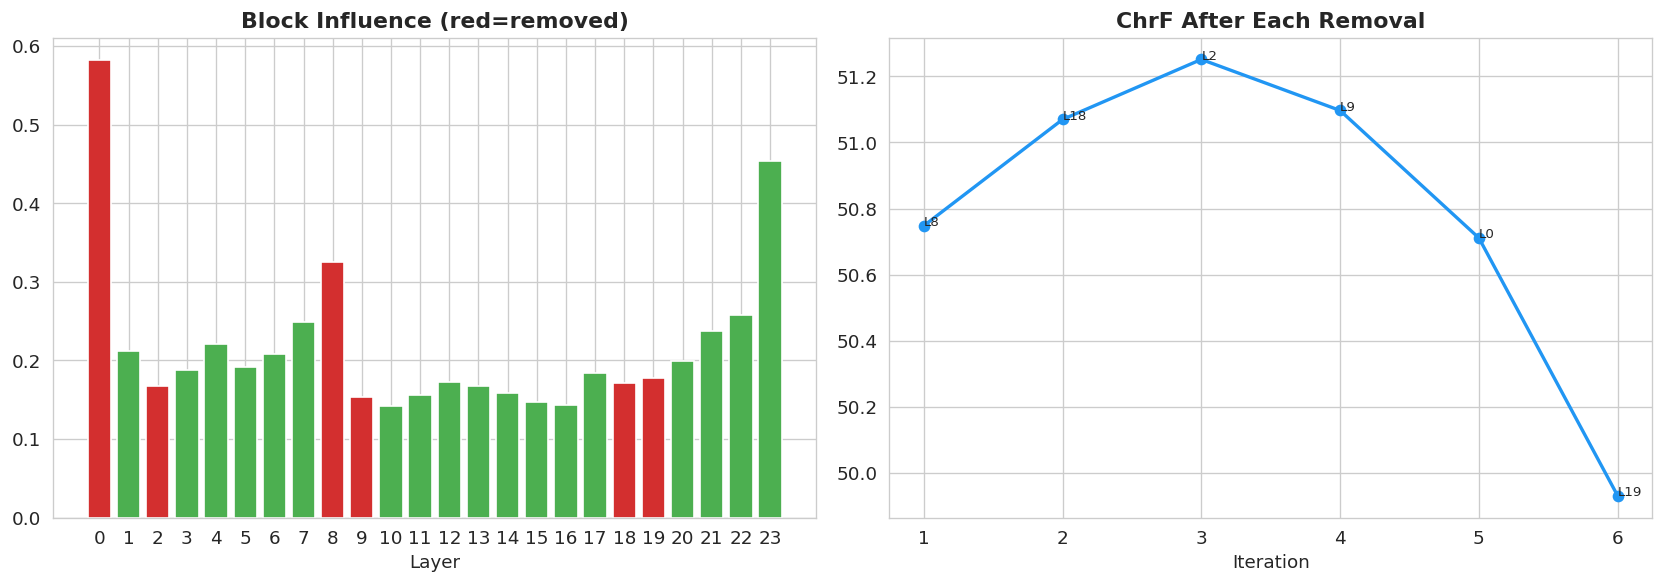

In [78]:
if bi_scores and p4_log:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    indices = sorted(bi_scores.keys())
    vals = [bi_scores[i] for i in indices]
    colors = ['#d32f2f' if i in removed_enc else '#4caf50' for i in indices]
    ax1.bar(indices, vals, color=colors, edgecolor='white')
    ax1.set_title('Block Influence (red=removed)', fontweight='bold')
    ax1.set_xlabel('Layer'); ax1.set_xticks(indices)
    iters = [e['iter'] for e in p4_log]
    ax2.plot(iters, [e['chrf'] for e in p4_log], 'o-', color='#2196F3', lw=2)
    for e in p4_log: ax2.annotate(f'L{e["removed"]}', (e['iter'], e['chrf']), fontsize=8)
    ax2.set_title('ChrF After Each Removal', fontweight='bold'); ax2.set_xlabel('Iteration')
    plt.tight_layout(); plt.savefig(f'{FIG_DIR}/phase4_enc.png'); plt.show()

[ckpt] No checkpoint for 'phase4_benchmark'

  BENCHMARK: P4_EncPrune
  Samples: 20  Target: ben

  GPU mem: 9.98 GB alloc / 9.99 GB reserved
  [ 1/20] BLEU= 12.3 ChrF= 50.0 RTF=0.090  id=1660
              pred: রোমান্টিকবাদ গথ, ফিচ এবং শ্লেগেলের মতো লেখকদের থেকে সাংস্কৃতিক নির্ধারিততার একটি
[audio] P4_EncPrune_s1in.wav (0.3 MB)
  P4_EncPrune_s1in.wav  (10.7s | sr=16000)


[audio] P4_EncPrune_s1out.wav (0.2 MB)
  P4_EncPrune_s1out.wav  (6.8s | sr=16000)


  [ 2/20] BLEU= 23.6 ChrF= 62.2 RTF=0.119  id=1662
              pred: অ্যালোয়েগুলি মূলত দুটি বা ততোধিক ধাতুর মিশ্রণ। পিআই টেবিলের উপর অনেক উপাদান রয়
[audio] P4_EncPrune_s2in.wav (0.3 MB)
  P4_EncPrune_s2in.wav  (8.4s | sr=16000)


[audio] P4_EncPrune_s2out.wav (0.2 MB)
  P4_EncPrune_s2out.wav  (6.7s | sr=16000)


  [ 3/20] BLEU=  3.7 ChrF= 32.6 RTF=0.122  id=1674
              pred: কিছু অঞ্চলে এক মিনিটের জন্য গরম পানি যথেষ্ট এবং অন্য কিছু ক্ষেত্রে কয়েক মিনিটের
  [ 4/20] BLEU= 17.2 ChrF= 46.9 RTF=0.085  id=1675
              pred: আপনার জন্য শব্দটির পাশে সমস্ত নাম সর্বদা একটি বড় অক্ষর দিয়ে শুরু হয়, এমনকি এক
  [ 5/20] BLEU=  5.2 ChrF= 31.7 RTF=0.126  id=1720
              pred: গরম চকোলেট বেলজিয়ামের স্ট্যান্ডার্ডের সাথে সামঞ্জস্যপূর্ণ। ফলের রস ব্যয়বহুল কি
  [ 6/20] BLEU=  4.5 ChrF= 47.1 RTF=0.097  id=1732
              pred: এই সময়কালকে সাধারণত উচ্চ মধ্যযুগ বা ইউরোপীয় ইতিহাসের সময়কাল বা 11th, 12th, 13
  [ 7/20] BLEU= 11.7 ChrF= 60.1 RTF=0.088  id=1740
              pred: পিরামিড সাউন্ড এন্ড লাইট শো শিশুদের জন্য এই এলাকার সবচেয়ে আকর্ষণীয় জিনিসগুলির 
  [ 8/20] BLEU= 12.1 ChrF= 53.9 RTF=0.106  id=1794
              pred: একটি সভ্যতা একটি অনন্য সংস্কৃতি যা একটি সমাজের একটি উল্লেখযোগ্য বড় গ্রুপ দ্বারা
  [ 9/20] BLEU= 22.6 ChrF= 61.7 RTF=0.071  id=1797
              pred: সবাই সমাজে অংশগ্র

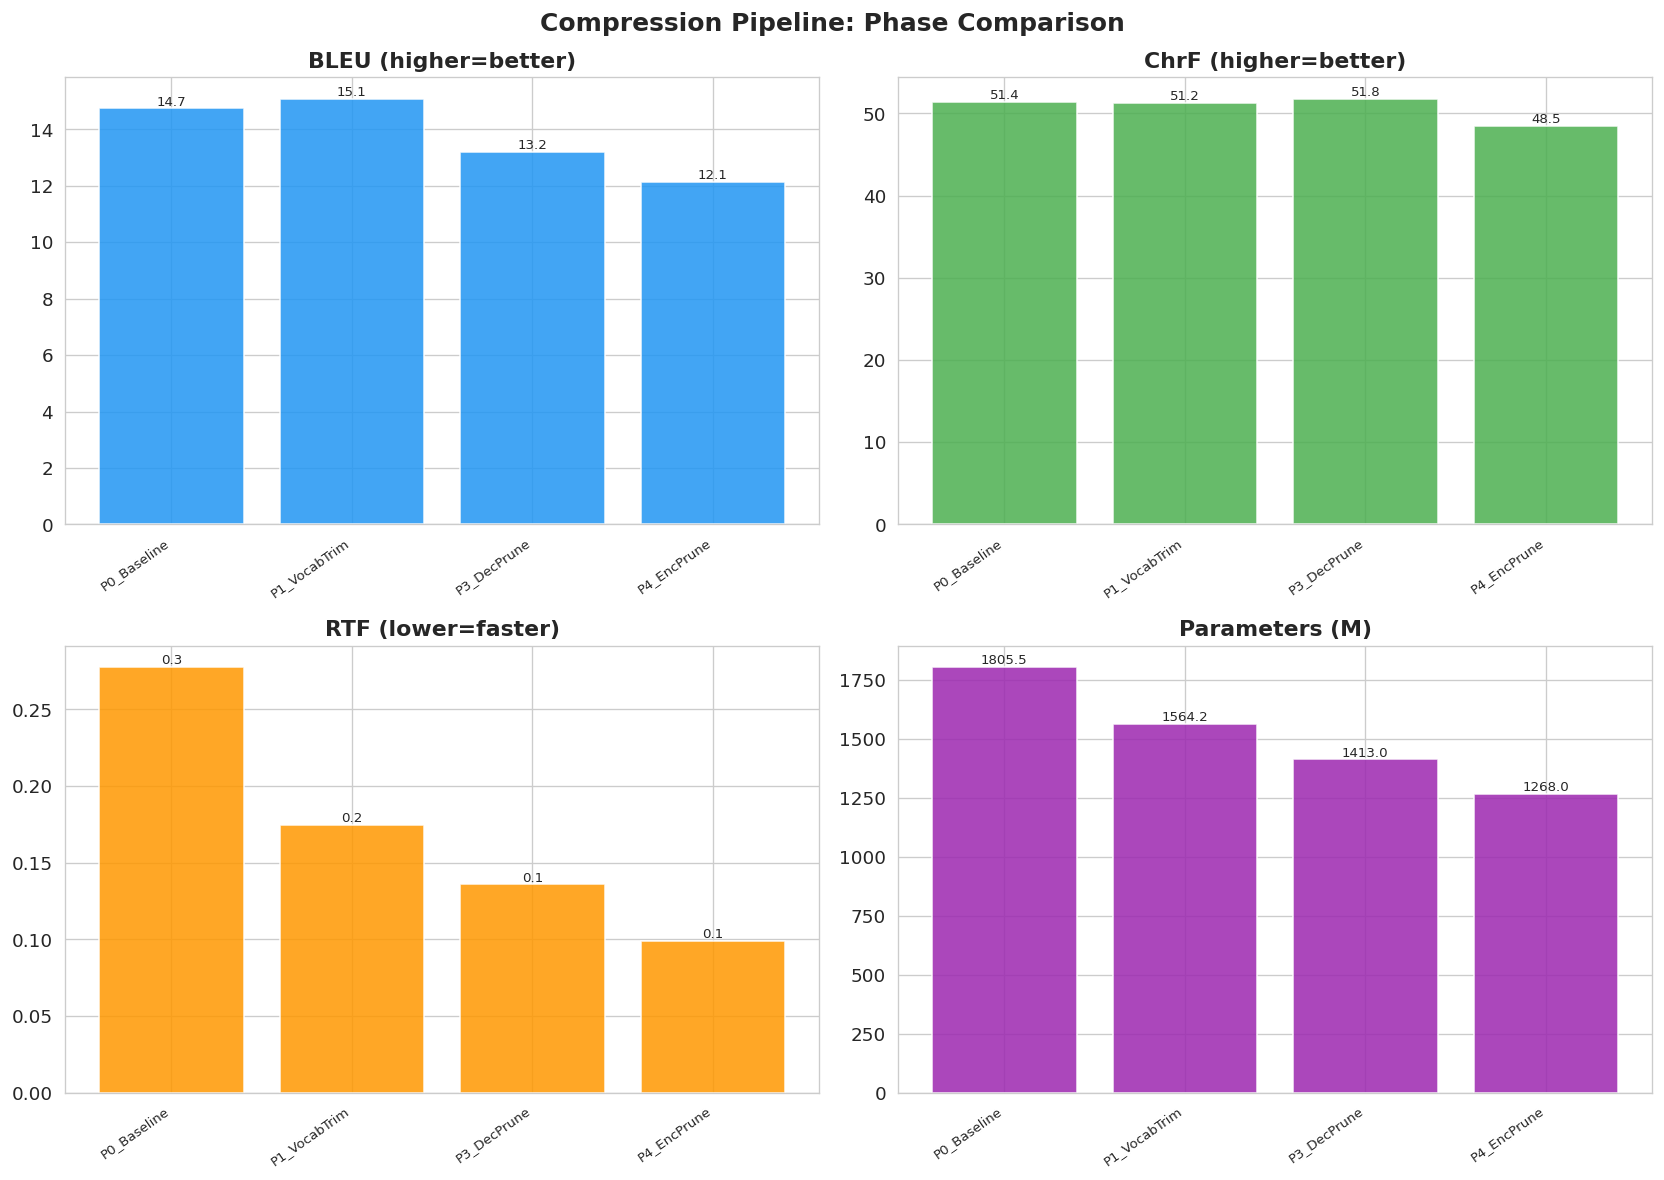

In [79]:
p4b = load_latest_checkpoint('phase4_benchmark')
if p4b: p4_results, p4_summary = p4b['results'], p4b['summary']
else:
    p4_results, p4_summary = run_benchmark(model_p4, eval_samples, label='P4_EncPrune', save_n=2)
    save_checkpoint(dict(results=p4_results, summary=p4_summary), name='phase4_benchmark', step=0)
store_summary(p4_summary); plot_phase_comparison()

---
# Phase 5: Width Pruning (FLAP)
**Paper:** FLAP (AAAI 2024)

Structurally remove FFN neurons (shrink weight matrices). Creates smaller dense
matrices for real GPU speedup, unlike zeroing which keeps full-size matrices.

In [80]:
def find_ffn_pair(layer):
    pairs = [('fc1','fc2'), ('intermediate_dense','output_dense'), ('linear1','linear2')]
    for n1, n2 in pairs:
        if hasattr(layer, n1) and hasattr(layer, n2): return n1, n2
    for cname, child in layer.named_children():
        for n1, n2 in pairs:
            if hasattr(child, n1) and hasattr(child, n2): return f'{cname}.{n1}', f'{cname}.{n2}'
    return None, None

def get_nested(obj, path):
    for p in path.split('.'): obj = getattr(obj, p)
    return obj

def set_nested(obj, path, val):
    parts = path.split('.')
    for p in parts[:-1]: obj = getattr(obj, p)
    setattr(obj, parts[-1], val)

def structural_prune_ffn(layer, fc1_name, fc2_name, ratio=0.25):
    fc1 = get_nested(layer, fc1_name)
    fc2 = get_nested(layer, fc2_name)
    w = fc1.weight.data.float()
    scores = w.abs().mean(dim=1)
    if fc1.bias is not None: scores += fc1.bias.data.float().abs()
    n_total = len(scores)
    n_keep = max(int(n_total * (1 - ratio)), 64)
    _, keep = torch.topk(scores, n_keep)
    keep = keep.sort().values
    new1 = nn.Linear(fc1.in_features, n_keep, bias=fc1.bias is not None)
    new1.weight.data = fc1.weight.data[keep].clone()
    if fc1.bias is not None: new1.bias.data = fc1.bias.data[keep].clone()
    new2 = nn.Linear(n_keep, fc2.out_features, bias=fc2.bias is not None)
    new2.weight.data = fc2.weight.data[:, keep].clone()
    if fc2.bias is not None: new2.bias.data = fc2.bias.data.clone()
    new1 = new1.to(fc1.weight.device, fc1.weight.dtype)
    new2 = new2.to(fc2.weight.device, fc2.weight.dtype)
    set_nested(layer, fc1_name, new1)
    set_nested(layer, fc2_name, new2)
    return n_total, n_keep

def apply_width_pruning(mdl, comp_name, ratio=0.25):
    parent = getattr(mdl, comp_name)
    la = find_layers_attr(parent)
    if la is None: print(f'  Skip {comp_name}'); return []
    layers = getattr(parent, la)
    stats = []
    for i, layer in enumerate(layers):
        n1, n2 = find_ffn_pair(layer)
        if n1 is None: continue
        nt, nk = structural_prune_ffn(layer, n1, n2, ratio)
        stats.append(dict(layer=i, total=nt, kept=nk))
        if i % 4 == 0: print(f'    L{i:>2}: {nt} -> {nk} ({nk/nt*100:.0f}%)')
    return stats

print('Width pruning functions ready.')

Width pruning functions ready.


In [81]:
FFN_PRUNE_RATIO = 0.25

try:
    model_p5, processor = load_model_from_drive('phase5_width_pruned')
    print('Loaded Phase 5 from Drive.')
except:
    print(f'Running Phase 5: width pruning at {FFN_PRUNE_RATIO*100:.0f}%...')
    model_p5 = model_p4
    pre = count_params(model_p5)
    stats = {}
    for comp in ['speech_encoder', 'text_decoder']:
        print(f'\n  Pruning {comp}...')
        stats[comp] = apply_width_pruning(model_p5, comp, FFN_PRUNE_RATIO)
    if hasattr(model_p5, 't2u_model') and model_p5.t2u_model is not None:
        print(f'\n  Pruning t2u_model...')
        stats['t2u_model'] = apply_width_pruning(model_p5, 't2u_model', FFN_PRUNE_RATIO)
    post = count_params(model_p5)
    print(f'\n  Width pruning: {pre:.1f}M to {post:.1f}M (saved {pre-post:.1f}M)')
    save_checkpoint(dict(stats=stats, ratio=FFN_PRUNE_RATIO), name='phase5_width', step=0)
    save_model_to_drive(model_p5, processor, 'phase5_width_pruned')

print_model_breakdown(model_p5, 'After Phase 5: Width Pruned')

[model] Downloading phase5_width_pruned from Drive...
Running Phase 5: width pruning at 25%...

  Pruning speech_encoder...
  Skip speech_encoder

  Pruning text_decoder...
    L 0: 8192 -> 6144 (75%)
    L 4: 8192 -> 6144 (75%)
    L 8: 8192 -> 6144 (75%)
    L12: 8192 -> 6144 (75%)
    L16: 8192 -> 6144 (75%)

  Pruning t2u_model...
  Skip t2u_model

  Width pruning: 1268.0M to 1192.4M (saved 75.5M)
[ckpt] Saved phase5_width_step000000.pt (0.0 MB)
[model] Saving phase5_width_pruned...
  config.decoder_ffn_dim: 8192 -> 6144
  Saved custom state: ['_vocab_remap_to_old']


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[model] Local OK: 2417 MB (7 files)  uploading...
[model] Done. Verified 7 files on Drive.

--- After Phase 5: Width Pruned ---
  speech_encoder                         490.0M  ( 41.1%)
  text_decoder                           398.8M  ( 33.4%)
  t2u_model                              261.8M  ( 22.0%)
  vocoder                                 41.9M  (  3.5%)
  shared                                  20.9M  (  1.8%)
  lm_head                                 20.9M  (  1.8%)
  TOTAL                                 1192.4M
---


{'shared': 20.9152,
 'speech_encoder': 489.964992,
 'text_decoder': 398.79168,
 'lm_head': 20.9152,
 't2u_model': 261.759747,
 'vocoder': 41.911362,
 'TOTAL': 1192.427781}

[ckpt] No checkpoint for 'phase5_benchmark'

  BENCHMARK: P5_WidthPrune
  Samples: 20  Target: ben

  GPU mem: 10.43 GB alloc / 10.64 GB reserved
  [ 1/20] BLEU=  2.8 ChrF= 34.6 RTF=0.098  id=1660
              pred: রোমান্টিকবাদ গোথ, ফিচচ এবং শ্লেগগের মতো লেখক থেকে সাংস্কৃতিক নির্ নির্ নির্ধারনব
[audio] P5_WidthPrune_s1in.wav (0.3 MB)
  P5_WidthPrune_s1in.wav  (10.7s | sr=16000)


[audio] P5_WidthPrune_s1out.wav (0.2 MB)
  P5_WidthPrune_s1out.wav  (6.4s | sr=16000)


  [ 2/20] BLEU= 12.0 ChrF= 35.4 RTF=0.098  id=1662
              pred: অ্যালগয় মূলত দুই বা বেশি ধাতুর মিশ্র, মনে রাখবেন পিআই আই টেবেলে অনেক উপাদান থাক
[audio] P5_WidthPrune_s2in.wav (0.3 MB)
  P5_WidthPrune_s2in.wav  (8.4s | sr=16000)


[audio] P5_WidthPrune_s2out.wav (0.2 MB)
  P5_WidthPrune_s2out.wav  (5.9s | sr=16000)


  [ 3/20] BLEU=  3.7 ChrF= 36.6 RTF=0.113  id=1674
              pred: কিছু জায়গায় এক মিনিটের জন্য boil water যথেষ্ট, অন্য জায়গায় কয়েক মিনিট।
  [ 4/20] BLEU=  2.5 ChrF=  8.0 RTF=0.068  id=1675
              pred: আপনার জন্য যে'' শব্দ, সব না,, শুরু, even,
  [ 5/20] BLEU=  2.7 ChrF= 19.0 RTF=0.118  id=1720
              pred: হট চকচচ বেলজিয়ামের মান পূরণ পূরণ করে। ফট রস দাপস, কিন্তু দাজ
  [ 6/20] BLEU=  0.4 ChrF= 15.8 RTF=0.449  id=1732
              pred: যে যুগ, যেখানে এই ঘটনা ঘটে, তাকে উচ্চ মধ্যযুগ, ইউরোপ ইতিহাসে, 11 12 13 - - - - -
  [ 7/20] BLEU=  9.3 ChrF= 34.8 RTF=0.069  id=1740
              pred: পিরামিড সাউন্ড অ্যান্ড লাইট শো শিশুদের এই অঞ্চল অন্যতম আকর্ষণিক।
  [ 8/20] BLEU= 14.2 ChrF= 44.5 RTF=0.088  id=1794
              pred: একটি সভ্যতা এমন একটি অনন্য সংস্কৃতি যা একটি উল্লেখযোগ্য বড় গ্রুপের মানুষ যারা স
  [ 9/20] BLEU=  5.5 ChrF= 35.8 RTF=0.055  id=1797
              pred: সমাজের যেখানে সবাই পরিবহন ব্যব ব্যববহার, প্রায় সবাইই অভিযোগ
  [10/20] BLEU=  4.7 ChrF= 32.6 RTF

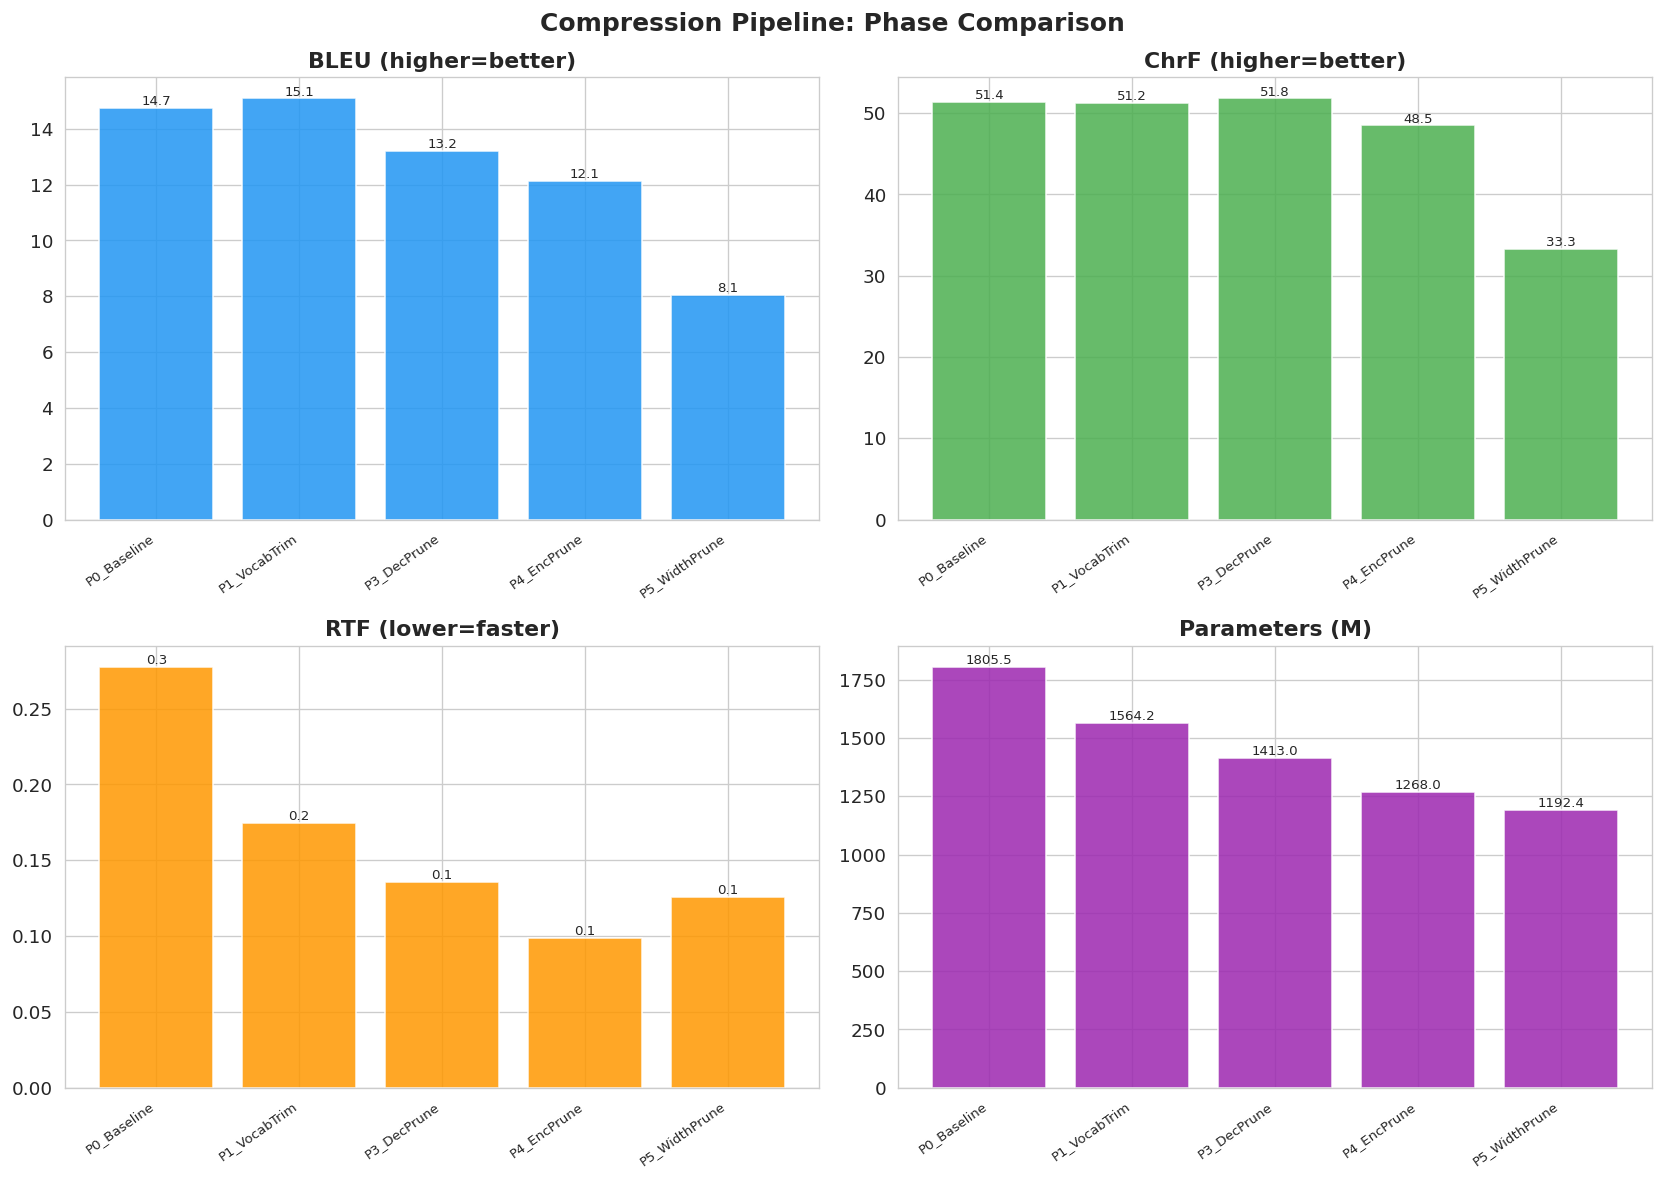

In [82]:
p5b = load_latest_checkpoint('phase5_benchmark')
if p5b: p5_results, p5_summary = p5b['results'], p5b['summary']
else:
    p5_results, p5_summary = run_benchmark(model_p5, eval_samples, label='P5_WidthPrune', save_n=2)
    save_checkpoint(dict(results=p5_results, summary=p5_summary), name='phase5_benchmark', step=0)
store_summary(p5_summary); plot_phase_comparison()

---
# Phase 6: T2U Model Pruning
Apply middle-layer removal to T2U transformer stacks (2-3 layers per stack).

In [83]:
try:
    model_p6, processor = load_model_from_drive('phase6_t2u_pruned')
    print('Loaded Phase 6 from Drive.')
except:
    model_p6 = model_p5
    if hasattr(model_p6, 't2u_model') and model_p6.t2u_model is not None:
        t2u = model_p6.t2u_model
        pre = count_params(t2u)
        for sub_name in ['encoder', 'decoder']:
            comp = getattr(t2u, sub_name, None)
            if comp is None:
                continue
            la = find_layers_attr(comp)
            if la is None:
                continue
            layers = getattr(comp, la)
            if len(layers) <= 3:
                continue
            n_rm = min(2, len(layers) - 2)
            mid = len(layers) // 2
            rm_idx = list(range(mid - n_rm//2, mid + (n_rm+1)//2))
            keep = [i for i in range(len(layers)) if i not in rm_idx]
            setattr(comp, la, nn.ModuleList([layers[i] for i in keep]))
            print(f'  t2u.{sub_name}.{la}: {len(layers)} -> {len(keep)} (removed {rm_idx})')
        post = count_params(t2u)
        print(f'  T2U: {pre:.1f}M to {post:.1f}M')
    else: print('  No T2U model.')
    save_model_to_drive(model_p6, processor, 'phase6_t2u_pruned')

print_model_breakdown(model_p6, 'After Phase 6: T2U Pruned')

[model] Downloading phase6_t2u_pruned from Drive...
  T2U: 261.8M to 261.8M
[model] Saving phase6_t2u_pruned...
  Saved custom state: ['_vocab_remap_to_old']


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[model] Local OK: 2417 MB (7 files)  uploading...
[model] Done. Verified 7 files on Drive.

--- After Phase 6: T2U Pruned ---
  speech_encoder                         490.0M  ( 41.1%)
  text_decoder                           398.8M  ( 33.4%)
  t2u_model                              261.8M  ( 22.0%)
  vocoder                                 41.9M  (  3.5%)
  shared                                  20.9M  (  1.8%)
  lm_head                                 20.9M  (  1.8%)
  TOTAL                                 1192.4M
---


{'shared': 20.9152,
 'speech_encoder': 489.964992,
 'text_decoder': 398.79168,
 'lm_head': 20.9152,
 't2u_model': 261.759747,
 'vocoder': 41.911362,
 'TOTAL': 1192.427781}

[ckpt] No checkpoint for 'phase6_benchmark'

  BENCHMARK: P6_T2UPrune
  Samples: 20  Target: ben

  GPU mem: 10.43 GB alloc / 11.62 GB reserved
  [ 1/20] BLEU=  2.8 ChrF= 34.6 RTF=0.095  id=1660
              pred: রোমান্টিকবাদ গোথ, ফিচচ এবং শ্লেগগের মতো লেখক থেকে সাংস্কৃতিক নির্ নির্ নির্ধারনব
[audio] P6_T2UPrune_s1in.wav (0.3 MB)
  P6_T2UPrune_s1in.wav  (10.7s | sr=16000)


[audio] P6_T2UPrune_s1out.wav (0.2 MB)
  P6_T2UPrune_s1out.wav  (6.4s | sr=16000)


  [ 2/20] BLEU= 12.0 ChrF= 35.4 RTF=0.098  id=1662
              pred: অ্যালগয় মূলত দুই বা বেশি ধাতুর মিশ্র, মনে রাখবেন পিআই আই টেবেলে অনেক উপাদান থাক
[audio] P6_T2UPrune_s2in.wav (0.3 MB)
  P6_T2UPrune_s2in.wav  (8.4s | sr=16000)


[audio] P6_T2UPrune_s2out.wav (0.2 MB)
  P6_T2UPrune_s2out.wav  (5.9s | sr=16000)


  [ 3/20] BLEU=  3.7 ChrF= 36.6 RTF=0.107  id=1674
              pred: কিছু জায়গায় এক মিনিটের জন্য boil water যথেষ্ট, অন্য জায়গায় কয়েক মিনিট।
  [ 4/20] BLEU=  2.5 ChrF=  8.0 RTF=0.066  id=1675
              pred: আপনার জন্য যে'' শব্দ, সব না,, শুরু, even,
  [ 5/20] BLEU=  2.7 ChrF= 19.0 RTF=0.117  id=1720
              pred: হট চকচচ বেলজিয়ামের মান পূরণ পূরণ করে। ফট রস দাপস, কিন্তু দাজ
  [ 6/20] BLEU=  0.4 ChrF= 15.8 RTF=0.440  id=1732
              pred: যে যুগ, যেখানে এই ঘটনা ঘটে, তাকে উচ্চ মধ্যযুগ, ইউরোপ ইতিহাসে, 11 12 13 - - - - -
  [ 7/20] BLEU=  9.3 ChrF= 34.8 RTF=0.067  id=1740
              pred: পিরামিড সাউন্ড অ্যান্ড লাইট শো শিশুদের এই অঞ্চল অন্যতম আকর্ষণিক।
  [ 8/20] BLEU= 14.2 ChrF= 44.5 RTF=0.086  id=1794
              pred: একটি সভ্যতা এমন একটি অনন্য সংস্কৃতি যা একটি উল্লেখযোগ্য বড় গ্রুপের মানুষ যারা স
  [ 9/20] BLEU=  5.5 ChrF= 35.8 RTF=0.052  id=1797
              pred: সমাজের যেখানে সবাই পরিবহন ব্যব ব্যববহার, প্রায় সবাইই অভিযোগ
  [10/20] BLEU=  4.7 ChrF= 32.6 RTF

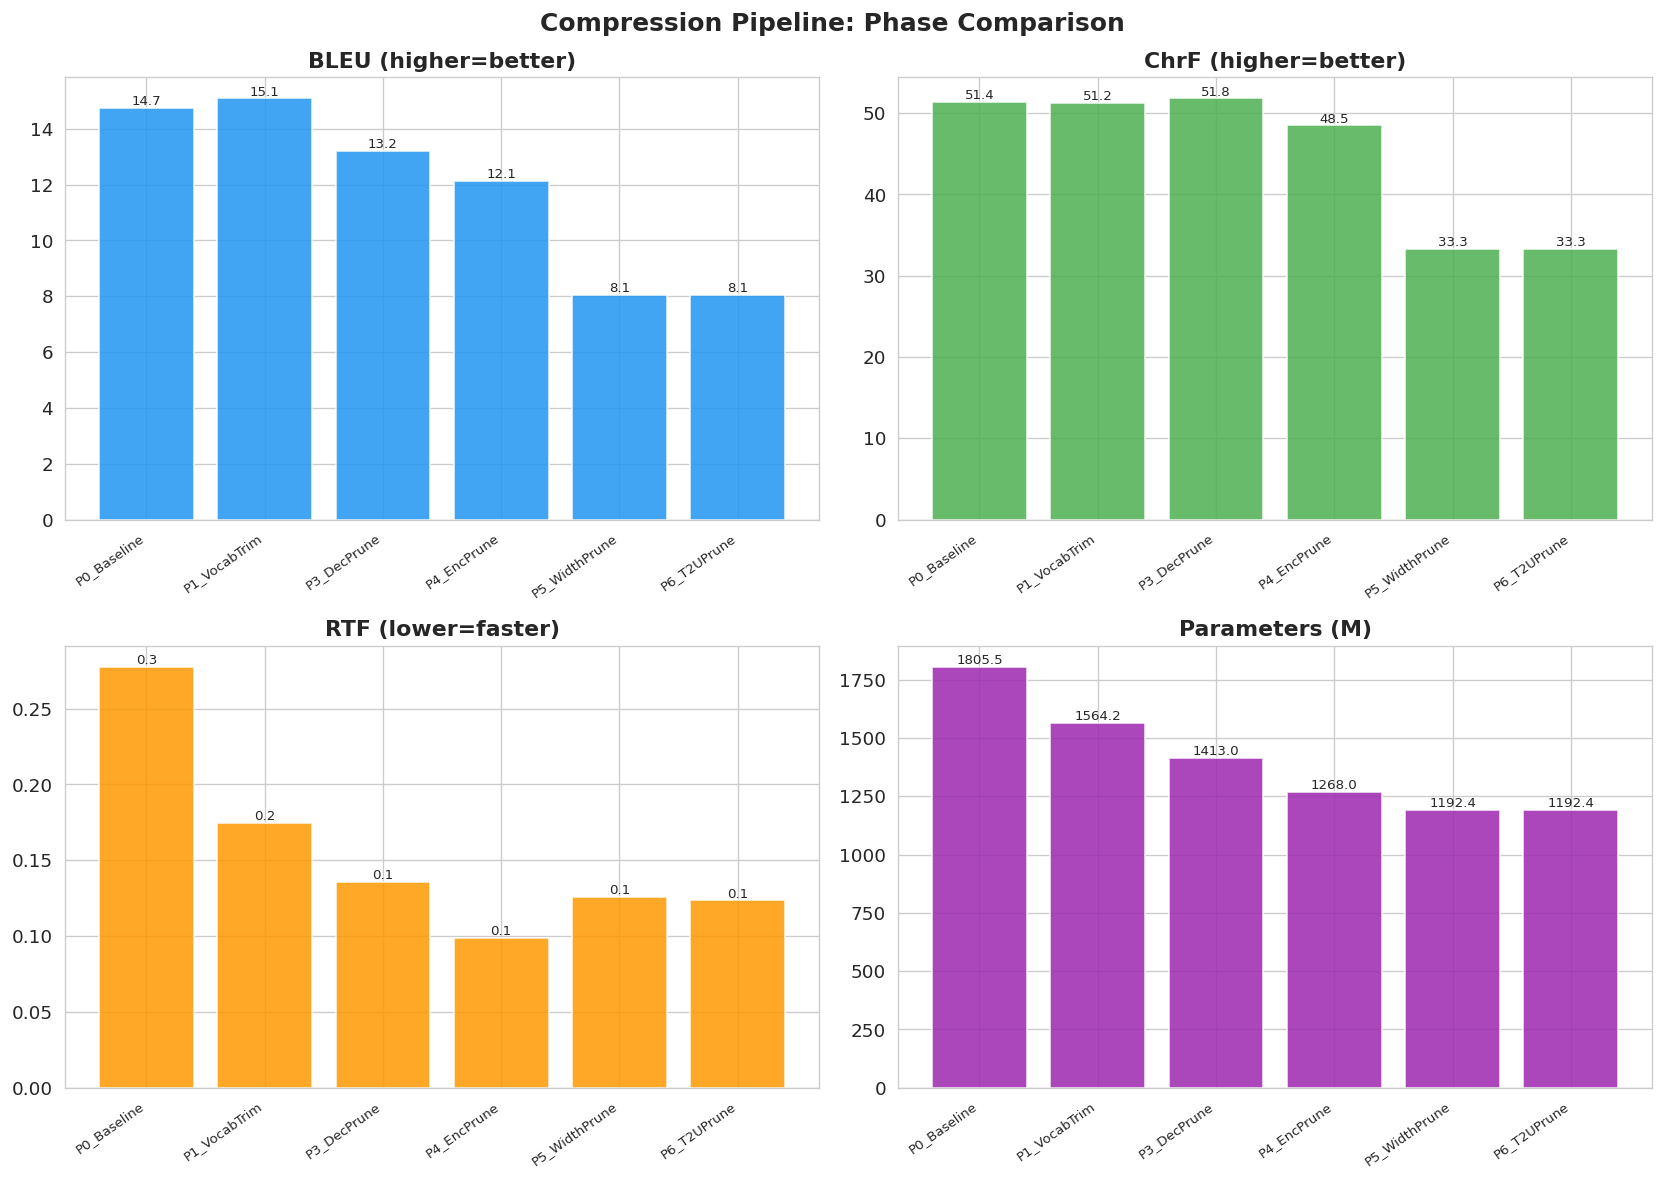

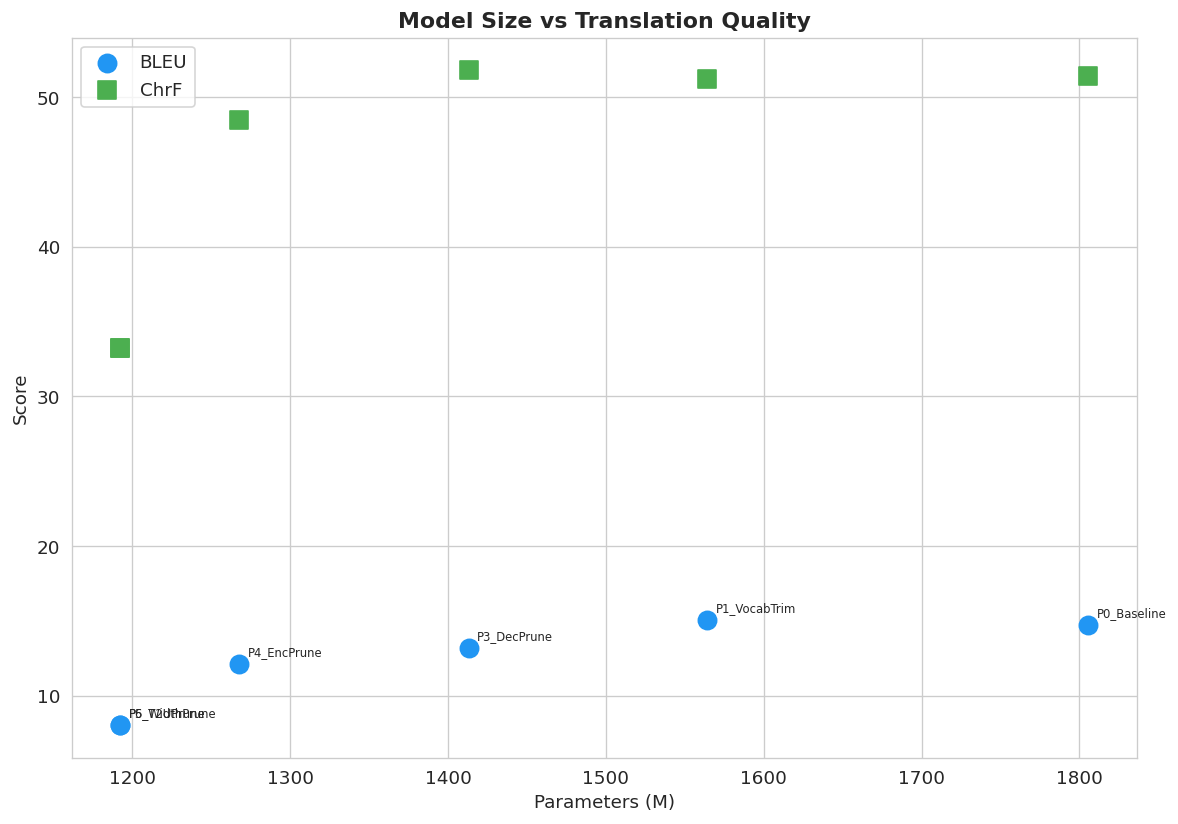

In [84]:
p6b = load_latest_checkpoint('phase6_benchmark')
if p6b: p6_results, p6_summary = p6b['results'], p6b['summary']
else:
    p6_results, p6_summary = run_benchmark(model_p6, eval_samples, label='P6_T2UPrune', save_n=2)
    save_checkpoint(dict(results=p6_results, summary=p6_summary), name='phase6_benchmark', step=0)
store_summary(p6_summary); plot_phase_comparison(); plot_size_vs_quality()

---
# Phase 7: Recovery Fine-tuning with LoRA
**Paper:** Moslem (IWSLT 2025)

Fine-tune using S2TT cross-entropy loss + LoRA for memory efficiency.

In [85]:
from datasets import load_dataset as ld
print('Loading FLEURS training data...')
ft_src = ld('google/fleurs', FLEURS_SRC, split='train', trust_remote_code=True)
ft_tgt = ld('google/fleurs', FLEURS_TGT, split='train', trust_remote_code=True)
fs = {ex['id']: ex for ex in ft_src}
ft = {ex['id']: ex for ex in ft_tgt}
ft_samples = []
for sid in sorted(set(fs) & set(ft)):
    wav = np.array(fs[sid]['audio']['array'], dtype=np.float32)
    sr = fs[sid]['audio']['sampling_rate']
    if sr != 16000: wav = torchaudio.functional.resample(torch.tensor(wav), sr, 16000).numpy()
    ft_samples.append(dict(wav=wav[:16000*15], ref=ft[sid]['transcription']))
print(f'Loaded {len(ft_samples)} training pairs.')

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'google/fleurs' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading FLEURS training data...


README.md: 0.00B [00:00, ?B/s]

fleurs.py: 0.00B [00:00, ?B/s]

RuntimeError: Dataset scripts are no longer supported, but found fleurs.py

In [ ]:
from peft import LoraConfig, get_peft_model
from torch.optim import AdamW
import random

MAX_STEPS, LOG_EVERY, SAVE_EVERY, LR = 2000, 50, 500, 1e-5

ft_ckpt = load_latest_checkpoint('phase7_ft')
start_step = ft_ckpt['step'] if ft_ckpt else 0

if start_step >= MAX_STEPS:
    print(f'Fine-tuning complete at step {start_step}.')
    try: model_p7, processor = load_model_from_drive('phase7_finetuned')
    except: model_p7 = model_p6
else:
    model_p7 = model_p6
    targets = set()
    for name, mod in model_p7.named_modules():
        if isinstance(mod, nn.Linear):
            sn = name.split('.')[-1]
            if sn in ['q_proj','k_proj','v_proj','out_proj','fc1','fc2']:
                targets.add(sn)
    targets = list(targets) or ['q_proj', 'v_proj']
    print(f'  LoRA targets: {targets}')

    try:
        model_p7 = get_peft_model(model_p7, LoraConfig(
            r=16, lora_alpha=32, target_modules=targets, lora_dropout=0.05, bias='none'))
        tr = sum(p.numel() for p in model_p7.parameters() if p.requires_grad)/1e6
        print(f'  LoRA trainable: {tr:.1f}M')
    except Exception as e:
        print(f'  LoRA failed ({e}), unfreezing speech_encoder only')
        for p in model_p7.parameters(): p.requires_grad = False
        for p in model_p7.speech_encoder.parameters(): p.requires_grad = True

    opt = AdamW([p for p in model_p7.parameters() if p.requires_grad], lr=LR)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, MAX_STEPS, eta_min=1e-7)
    if ft_ckpt and 'opt' in ft_ckpt:
        try: opt.load_state_dict(ft_ckpt['opt'])
        except: pass

    model_p7.train()
    loss_log = ft_ckpt.get('loss_log', []) if ft_ckpt else []
    step = start_step
    random.shuffle(ft_samples)
    print(f'\n  Starting from step {step}...')

    while step < MAX_STEPS:
        s = ft_samples[step % len(ft_samples)]
        try:
            inputs = processor(audio=s['wav'], sampling_rate=16000, return_tensors='pt')
            _dev = _model_input_device(model_p7)
            inputs = {k: v.to(_dev) for k, v in inputs.items()}
            labels = processor.tokenizer(text=s['ref'], return_tensors='pt',
                                        padding=True).input_ids.to(_dev)
            opt.zero_grad()
            with torch.amp.autocast('cuda', dtype=torch.float16):
                loss = model_p7(**inputs, labels=labels).loss
            if torch.isnan(loss): continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_p7.parameters(), 1.0)
            opt.step(); sched.step()
            loss_log.append(loss.item()); step += 1
            if step % LOG_EVERY == 0:
                print(f'  Step {step:>5}/{MAX_STEPS}  loss={np.mean(loss_log[-LOG_EVERY:]):.4f}  lr={sched.get_last_lr()[0]:.2e}')
            if step % SAVE_EVERY == 0:
                save_checkpoint(dict(step=step, loss_log=loss_log, opt=opt.state_dict()),
                                name='phase7_ft', step=step)
        except RuntimeError as e:
            if 'out of memory' in str(e): torch.cuda.empty_cache(); continue
            raise

    model_p7.eval()
    if hasattr(model_p7, 'merge_and_unload'):
        print('  Merging LoRA weights...')
        model_p7 = model_p7.merge_and_unload()
    print(f'  Done. Final loss: {np.mean(loss_log[-50:]):.4f}')
    save_model_to_drive(model_p7, processor, 'phase7_finetuned')

In [ ]:
ft_ckpt = load_latest_checkpoint('phase7_ft')
if ft_ckpt and 'loss_log' in ft_ckpt:
    losses = ft_ckpt['loss_log']
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(losses, alpha=0.3, color='steelblue', lw=0.5, label='Raw')
    ema, val = [], losses[0]
    for l in losses: val = 0.02*l + 0.98*val; ema.append(val)
    ax.plot(ema, color='firebrick', lw=2, label='EMA')
    ax.set_xlabel('Step'); ax.set_ylabel('Loss')
    ax.set_title('Phase 7: Fine-tuning Loss', fontweight='bold')
    ax.legend(); plt.tight_layout(); plt.savefig(f'{FIG_DIR}/phase7_loss.png'); plt.show()

In [ ]:
p7b = load_latest_checkpoint('phase7_benchmark')
if p7b: p7_results, p7_summary = p7b['results'], p7b['summary']
else:
    p7_results, p7_summary = run_benchmark(model_p7, eval_samples, label='P7_FineTuned', save_n=4)
    save_checkpoint(dict(results=p7_results, summary=p7_summary), name='phase7_benchmark', step=0)
store_summary(p7_summary); plot_phase_comparison()

---
# Phase 8: Final Results + Paper Table

In [ ]:
sc = load_latest_checkpoint('all_summaries')
if sc and 'summaries' in sc: ALL_SUMMARIES = sc['summaries']

print('\n' + '='*80)
print('  FINAL: SeamlessM4T v2 Large  Structured Compression')
print('  Task: English to Bengali Speech Translation (FLEURS test)')
print('='*80)
hdr = f'{"Phase":<25} {"Params(M)":>10} {"Delta":>8} {"BLEU":>7} {"ChrF":>7} {"RTF":>7}'
print(hdr); print('-'*len(hdr))
bp = ALL_SUMMARIES[0]['params_M'] if ALL_SUMMARIES else 2300
for s in ALL_SUMMARIES:
    d = (1 - s['params_M']/bp)*100 if bp else 0
    ds = f'-{d:.1f}%' if d > 0 else 'base'
    print(f'  {s["label"]:<23} {s["params_M"]:>8.1f}  {ds:>7}  {s["avg_bleu"]:>6.2f}  {s["avg_chrf"]:>6.2f}  {s["avg_rtf"]:>6.4f}')
print('='*80)
if len(ALL_SUMMARIES) >= 2:
    f, b = ALL_SUMMARIES[-1], ALL_SUMMARIES[0]
    print(f'  Param reduction: {(1-f["params_M"]/b["params_M"])*100:.1f}%')
    print(f'  Speed (RTF): {b["avg_rtf"]/f["avg_rtf"]:.2f}x faster' if f['avg_rtf']>0 else '')

In [ ]:
if len(ALL_SUMMARIES) >= 2:
    fig = plt.figure(figsize=(18, 12))
    fig.suptitle('SeamlessM4T Compression Pipeline Results', fontsize=16, fontweight='bold')
    labels = [s['label'] for s in ALL_SUMMARIES]
    x = range(len(labels))

    ax1 = fig.add_subplot(2, 3, 1)
    ps = [s['params_M'] for s in ALL_SUMMARIES]
    ax1.bar(x, ps, color='#9C27B0', alpha=0.85)
    ax1.set_ylabel('Params (M)'); ax1.set_title('Model Size', fontweight='bold')
    ax1.set_xticks(x); ax1.set_xticklabels(labels, rotation=40, ha='right', fontsize=7)

    ax2 = fig.add_subplot(2, 3, 2)
    ax2.plot(x, [s['avg_bleu'] for s in ALL_SUMMARIES], 'o-', color='#2196F3', lw=2)
    ax2.set_ylabel('BLEU'); ax2.set_title('BLEU (higher=better)', fontweight='bold')
    ax2.set_xticks(x); ax2.set_xticklabels(labels, rotation=40, ha='right', fontsize=7)

    ax3 = fig.add_subplot(2, 3, 3)
    ax3.plot(x, [s['avg_chrf'] for s in ALL_SUMMARIES], 's-', color='#4CAF50', lw=2)
    ax3.set_ylabel('ChrF'); ax3.set_title('ChrF (higher=better)', fontweight='bold')
    ax3.set_xticks(x); ax3.set_xticklabels(labels, rotation=40, ha='right', fontsize=7)

    ax4 = fig.add_subplot(2, 3, 4)
    ax4.bar(x, [s['avg_rtf'] for s in ALL_SUMMARIES], color='#FF9800', alpha=0.85)
    ax4.set_ylabel('RTF'); ax4.set_title('RTF (lower=faster)', fontweight='bold')
    ax4.set_xticks(x); ax4.set_xticklabels(labels, rotation=40, ha='right', fontsize=7)

    ax5 = fig.add_subplot(2, 3, 5)
    ax5.scatter(ps, [s['avg_bleu'] for s in ALL_SUMMARIES], s=100, c='#2196F3', label='BLEU')
    ax5.scatter(ps, [s['avg_chrf'] for s in ALL_SUMMARIES], s=100, c='#4CAF50', marker='s', label='ChrF')
    ax5.set_xlabel('Params (M)'); ax5.set_ylabel('Score')
    ax5.set_title('Size vs Quality', fontweight='bold'); ax5.legend(fontsize=8)

    ax6 = fig.add_subplot(2, 3, 6)
    bp = ALL_SUMMARIES[0]['params_M'] or 1
    bb = ALL_SUMMARIES[0]['avg_bleu'] or 1
    bc = ALL_SUMMARIES[0]['avg_chrf'] or 1
    comp = [(1-s['params_M']/bp)*100 for s in ALL_SUMMARIES]
    ax6.plot(comp, [s['avg_bleu']/bb*100 for s in ALL_SUMMARIES], 'o-', color='#2196F3', label='BLEU %')
    ax6.plot(comp, [s['avg_chrf']/bc*100 for s in ALL_SUMMARIES], 's-', color='#4CAF50', label='ChrF %')
    ax6.axhline(y=90, color='gray', ls='--', alpha=0.5)
    ax6.set_xlabel('Compression %'); ax6.set_ylabel('Quality Retention %')
    ax6.set_title('Compression vs Quality', fontweight='bold'); ax6.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/final_comprehensive.png', dpi=150); plt.show()
    subprocess.run(f'rclone sync {FIG_DIR} {GDRIVE_ROOT}/figures/', shell=True)
    print('All figures synced to Drive.')

In [ ]:
print('\nDone. All results saved to Drive.')
session_status()